# MADOS-SIH V3 — SeaRel-SR-UNet
## Sea-Relative Spectral Contrast as an Inductive Bias

V3 is a **controlled extension of the successful V2.1 model**.

### Reference results
- **V1 validation mIoU:** ~0.66548
- **V1 validation mF1:** ~0.76212
- **V2.1 validation mIoU:** **0.67840**
- **V2.1 validation mF1:** **0.77442**
- Rejected large V2 validation mIoU: 0.61358

### New V3 inductive bias

A marine target is represented not only by its absolute multispectral signature, but also by **how its spectrum differs from the surrounding marine context**.

For each pixel, V3 constructs **Local Spectral Contrast Coordinates (LSCC)**:

1. multi-scale annular context spectra
2. relative spectral residual
3. log spectral ratio
4. spectral angle to local context

The new LSCC branch is fused residually into the winning V2.1 spectral representation.

```text
                   11-band normalized Sentinel-2
                              │
                 ┌────────────┴────────────┐
                 │                         │
                 ▼                         ▼
       V2.1 absolute spectral       Sea-relative LSCC
              stem                      branch
                 │                         │
                 │             de-normalize reflectance
                 │                         │
                 │             annular context at
                 │             9 / 21 / 41 px scales
                 │                         │
                 │              Δ spectrum / log-ratio
                 │                 / spectral angle
                 │                         │
                 │                  1×1 LSCC encoder
                 │                         │
                 └────────────┬────────────┘
                              ▼
                       bounded residual fusion
                              │
                              ▼
                    original V1 residual U-Net
                              │
                              ▼
                       15-class segmentation
```

The LSCC contribution starts small and is bounded, so the initial model remains close to V2.1.

**Test evaluation is disabled by default.**

In [1]:

# =========================
# 0. USER CONFIG
# =========================

DATASET_NAME = "mados-sih"

# Kaggle may mount a dataset slug with "-" instead of "_".
# The notebook auto-detects both and searches nested folders.
KAGGLE_INPUT = "/kaggle/input"
EXPLICIT_DATA_ROOT = "/kaggle/input/datasets/rickastley223/mados-sih/MADOS"
WORKDIR = "/kaggle/working/mados_sih_v3_searel"

SEED = 42

# Fast correctness test before full training.
RUN_OVERFIT_TEST = True
OVERFIT_SAMPLES = 20
OVERFIT_EPOCHS = 40

# Full run.
RUN_FULL_TRAINING = True
EPOCHS = 80
BATCH_SIZE = 6
NUM_WORKERS = 4

# Optimization.
LR = 3e-4
WEIGHT_DECAY = 1e-4
WARMUP_EPOCHS = 5
GRAD_CLIP = 1.0
EARLY_STOPPING_PATIENCE = 15

# Model.
MODEL_WIDTH = 48
DROPOUT = 0.10

# V2.1 only new model component.
SPECTRAL_HIDDEN = 32
SPECTRAL_RESIDUAL_SCALE_INIT = 0.10

# V3: Local Spectral Contrast Coordinates (LSCC).
# Each pair is (inner box, outer box) for an annular context.
LSCC_RING_PAIRS = ((3, 9), (7, 21), (15, 41))
LSCC_HIDDEN = 48

# Raw-reflectance numerical stability.
LSCC_EPS = 1e-4
LSCC_DELTA_CLIP = 4.0
LSCC_LOG_RATIO_CLIP = 4.0

# V3 starts close to V2.1.
LSCC_GATE_INIT = 0.05
LSCC_GATE_MAX = 0.50


# Data.
IMAGE_SIZE = 240
RESAMPLING = "nearest"      # "nearest" = reference-like baseline; "bilinear" = ablation
USE_AUGMENTATION = True
USE_RARE_CLASS_SAMPLER = True

# Supervision.
USE_CONFIDENCE_WEIGHTING = True
CONF_HIGH = 1.00
CONF_MEDIUM = 0.67
CONF_LOW = 0.33

CE_WEIGHT = 0.60
DICE_WEIGHT = 0.40

# Runtime.
USE_AMP = True
USE_EMA = True
EMA_DECAY = 0.999
DETERMINISTIC = False

# Inference.
USE_TTA_ON_TEST = True

# Keep False while selecting/tuning V3.
RUN_FINAL_TEST = False

print("Configuration loaded.")


Configuration loaded.


In [2]:

# =========================
# 1. IMPORTS + REPRODUCIBILITY
# =========================

import os
import re
import gc
import json
import math
import random
import warnings
from pathlib import Path
from glob import glob
from collections import Counter, defaultdict
from dataclasses import dataclass, asdict
from typing import Dict, List, Tuple, Optional

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import rasterio
from rasterio.enums import Resampling
from rasterio.errors import NotGeoreferencedWarning

warnings.filterwarnings('ignore', category=NotGeoreferencedWarning)
warnings.filterwarnings(
    'ignore',
    message='Dataset has no geotransform, gcps, or rpcs.*',
)

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler, Subset
from tqdm.auto import tqdm

os.makedirs(WORKDIR, exist_ok=True)

def seed_everything(seed=42, deterministic=False):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    if deterministic:
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False
    else:
        torch.backends.cudnn.deterministic = False
        torch.backends.cudnn.benchmark = True

seed_everything(SEED, DETERMINISTIC)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)
if DEVICE.type == "cuda":
    print("GPU:", torch.cuda.get_device_name(0))
    print("CUDA:", torch.version.cuda)
print("PyTorch:", torch.__version__)


Device: cuda
GPU: Tesla T4
CUDA: 12.8
PyTorch: 2.10.0+cu128


## 2. Resolve the Kaggle dataset path

This notebook now uses your exact Kaggle MADOS root first:

```text
/kaggle/input/datasets/rickastley223/mados-sih/MADOS
```

So the first scene is expected at:

```text
/kaggle/input/datasets/rickastley223/mados-sih/MADOS/Scene_0
```

If the mount layout changes, the notebook still has a fallback search.


In [3]:
# =========================
# 2. RESOLVE MADOS ROOT
# =========================

def looks_like_mados_root(path: Path) -> bool:
    if not path.is_dir():
        return False
    has_scenes = any(
        p.is_dir() and p.name.startswith("Scene_")
        for p in path.iterdir()
    )
    has_splits = (path / "splits").is_dir()
    return has_scenes and has_splits

def discover_mados_root() -> Path:
    # 1) Your exact Kaggle dataset root.
    explicit = Path(EXPLICIT_DATA_ROOT)
    if explicit.exists() and looks_like_mados_root(explicit):
        return explicit

    # 2) Common mount variants.
    candidates = [
        Path("/kaggle/input/datasets/rickastley223/mados-sih/MADOS"),
        Path("/kaggle/input/datasets/rickastley223/mados-sih"),
        Path(KAGGLE_INPUT) / DATASET_NAME,
        Path(KAGGLE_INPUT) / DATASET_NAME.replace("_", "-"),
        Path(KAGGLE_INPUT) / DATASET_NAME.replace("-", "_"),
    ]

    for c in candidates:
        for p in [c, c / "MADOS", c / "mados"]:
            if p.exists() and looks_like_mados_root(p):
                return p

    # 3) Recursive fallback.
    input_root = Path(KAGGLE_INPUT)
    if input_root.exists():
        for p in input_root.rglob("*"):
            if p.is_dir():
                try:
                    if looks_like_mados_root(p):
                        return p
                except PermissionError:
                    continue

    raise FileNotFoundError(
        "Could not locate the MADOS root. "
        f"Tried explicit path: {EXPLICIT_DATA_ROOT}"
    )

DATA_ROOT = discover_mados_root()

print("Resolved DATA_ROOT:", DATA_ROOT)
print("Scene_0 exists:", (DATA_ROOT / "Scene_0").exists())
print("splits exists:", (DATA_ROOT / "splits").exists())

print("\nTop-level entries:")
for p in sorted(DATA_ROOT.iterdir())[:30]:
    print(" ", p.name)

Resolved DATA_ROOT: /kaggle/input/datasets/rickastley223/mados-sih/MADOS
Scene_0 exists: True
splits exists: True

Top-level entries:
  Scene_0
  Scene_1
  Scene_10
  Scene_100
  Scene_101
  Scene_102
  Scene_103
  Scene_104
  Scene_105
  Scene_106
  Scene_107
  Scene_108
  Scene_109
  Scene_11
  Scene_110
  Scene_111
  Scene_112
  Scene_113
  Scene_114
  Scene_115
  Scene_116
  Scene_117
  Scene_118
  Scene_119
  Scene_12
  Scene_120
  Scene_121
  Scene_122
  Scene_123
  Scene_124


In [4]:

# =========================
# 3. DATASET CONSTANTS
# =========================

NUM_CLASSES = 15
IN_CHANNELS = 11
IGNORE_INDEX = -1

CLASS_NAMES = [
    "Marine Debris",
    "Dense Sargassum",
    "Sparse Floating Algae",
    "Natural Organic Material",
    "Ship",
    "Oil Spill",
    "Marine Water",
    "Sediment-Laden Water",
    "Foam",
    "Turbid Water",
    "Shallow Water",
    "Waves & Wakes",
    "Oil Platform",
    "Jellyfish",
    "Sea Snot",
]

# Published reference statistics used by the official MADOS code.
BAND_MEAN = np.array(
    [0.0582676, 0.05223386, 0.04381474, 0.0357083, 0.03412902,
     0.03680401, 0.03999107, 0.03566642, 0.03965081, 0.0267993,
     0.01978944], dtype=np.float32
)

BAND_STD = np.array(
    [0.03240627, 0.03432253, 0.0354812, 0.0375769, 0.03785412,
     0.04992323, 0.05884482, 0.05545856, 0.06423746, 0.04211187,
     0.03019115], dtype=np.float32
)

def read_split_file(path: Path) -> List[str]:
    vals = np.genfromtxt(path, dtype=str)
    if np.ndim(vals) == 0:
        vals = np.array([str(vals)])
    return vals.tolist()

def find_split_file(mode: str) -> Path:
    split_dir = DATA_ROOT / "splits"
    candidates = [
        split_dir / f"{mode}_X.txt",
        split_dir / f"{mode}.txt",
        split_dir / f"{mode}_x.txt",
    ]
    for p in candidates:
        if p.exists():
            return p

    # Fuzzy fallback.
    hits = sorted(split_dir.glob(f"*{mode}*"))
    txt_hits = [p for p in hits if p.suffix.lower() == ".txt"]
    if txt_hits:
        return txt_hits[0]
    raise FileNotFoundError(f"No split file found for '{mode}' in {split_dir}")

SPLIT_FILES = {}
for mode in ["train", "val", "test"]:
    try:
        SPLIT_FILES[mode] = find_split_file(mode)
        print(mode, "->", SPLIT_FILES[mode])
    except FileNotFoundError:
        print(mode, "-> not found")


train -> /kaggle/input/datasets/rickastley223/mados-sih/MADOS/splits/train_X.txt
val -> /kaggle/input/datasets/rickastley223/mados-sih/MADOS/splits/val_X.txt
test -> /kaggle/input/datasets/rickastley223/mados-sih/MADOS/splits/test_X.txt


In [5]:

# =========================
# 4. BUILD A ROBUST FILE INDEX
# =========================

def band_number(path: str) -> int:
    name = os.path.basename(path)
    m = re.search(r"L2R_rhorc_(\d+)", name)
    if not m:
        # Fallback to last integer chunk before crop suffix.
        ints = re.findall(r"(\d+)", name)
        if not ints:
            raise ValueError(f"Cannot identify spectral band from: {name}")
        return int(ints[-1])
    return int(m.group(1))

def resolve_all_samples() -> Dict[str, Dict]:
    index = {}

    scene_dirs = sorted([p for p in DATA_ROOT.iterdir()
                         if p.is_dir() and p.name.startswith("Scene_")])

    print("Scene folders:", len(scene_dirs))

    for scene_dir in tqdm(scene_dirs, desc="Indexing scenes"):
        # Class masks should be in the 10 m folder in the canonical dataset.
        mask_candidates = sorted((scene_dir / "10").glob("*_cl_*.tif"))

        # Fallback if mirror changed layout.
        if not mask_candidates:
            mask_candidates = sorted(scene_dir.rglob("*_cl_*.tif"))

        for mask_path in mask_candidates:
            if "_cl_" not in mask_path.name:
                continue

            crop = mask_path.name.split("_cl_", 1)[1]
            crop_stem = crop[:-4] if crop.lower().endswith(".tif") else crop
            sample_id = f"{scene_dir.name}_{crop_stem}"

            band_paths = sorted(
                glob(str(scene_dir / "*" / f"*L2R_rhorc*_{crop}")),
                key=band_number
            )

            conf_candidates = list(scene_dir.rglob(f"*_conf_{crop}"))
            conf_path = str(conf_candidates[0]) if conf_candidates else None

            index[sample_id] = {
                "id": sample_id,
                "scene": scene_dir.name,
                "crop": crop,
                "bands": band_paths,
                "mask": str(mask_path),
                "confidence": conf_path,
            }

    return index

ALL_INDEX = resolve_all_samples()
print("Total indexed samples:", len(ALL_INDEX))

# Split membership.
SPLIT_IDS = {}
for mode, path in SPLIT_FILES.items():
    SPLIT_IDS[mode] = read_split_file(path)
    print(f"{mode:5s}: {len(SPLIT_IDS[mode])}")

# Leakage / overlap checks.
if "train" in SPLIT_IDS and "val" in SPLIT_IDS:
    overlap = set(SPLIT_IDS["train"]) & set(SPLIT_IDS["val"])
    print("train ∩ val:", len(overlap))

if "train" in SPLIT_IDS and "test" in SPLIT_IDS:
    overlap = set(SPLIT_IDS["train"]) & set(SPLIT_IDS["test"])
    print("train ∩ test:", len(overlap))

if "val" in SPLIT_IDS and "test" in SPLIT_IDS:
    overlap = set(SPLIT_IDS["val"]) & set(SPLIT_IDS["test"])
    print("val ∩ test:", len(overlap))

# Confirm every split item resolved.
for mode, ids in SPLIT_IDS.items():
    missing = [x for x in ids if x not in ALL_INDEX]
    print(f"{mode:5s}: unresolved = {len(missing)}")
    if missing[:5]:
        print(" examples:", missing[:5])


Scene folders: 174


Indexing scenes:   0%|          | 0/174 [00:00<?, ?it/s]

Total indexed samples: 2803
train: 1433
val  : 642
test : 728
train ∩ val: 0
train ∩ test: 0
val ∩ test: 0
train: unresolved = 0
val  : unresolved = 0
test : unresolved = 0



## 5. Integrity audit

This checks the things that can silently ruin a remote-sensing experiment:

- exactly 11 spectral rasters per sample
- class mask shape
- confidence-mask shape
- valid class IDs
- NaNs / infinities
- split resolution
- per-class pixel counts
- per-confidence pixel counts


In [6]:

# =========================
# 5. DATASET AUDIT
# =========================

def read_raster_1(path: str) -> np.ndarray:
    with rasterio.open(path) as src:
        return src.read(1)

audit_rows = []
class_counts = Counter()
confidence_counts = Counter()
bad_samples = []

AUDIT_MODES = ["train", "val"] + (["test"] if RUN_FINAL_TEST and "test" in SPLIT_IDS else [])

for mode in AUDIT_MODES:
    ids = SPLIT_IDS[mode]
    for sample_id in tqdm(ids, desc=f"Audit {mode}"):
        if sample_id not in ALL_INDEX:
            bad_samples.append((sample_id, mode, "unresolved sample"))
            continue

        s = ALL_INDEX[sample_id]

        if len(s["bands"]) != IN_CHANNELS:
            bad_samples.append(
                (sample_id, mode, f"band_count={len(s['bands'])}")
            )
            continue

        try:
            mask = read_raster_1(s["mask"]).astype(np.int64)
            unique = np.unique(mask)

            if mask.shape != (IMAGE_SIZE, IMAGE_SIZE):
                bad_samples.append(
                    (sample_id, mode, f"mask_shape={mask.shape}")
                )

            invalid = unique[(unique < 0) | (unique > 15)]
            if len(invalid):
                bad_samples.append(
                    (sample_id, mode, f"invalid_labels={invalid.tolist()}")
                )

            if mode == "train":
                vals, cnts = np.unique(mask, return_counts=True)
                for v, c in zip(vals, cnts):
                    class_counts[int(v)] += int(c)

                if s["confidence"] is not None:
                    conf = read_raster_1(s["confidence"]).astype(np.int64)
                    vals, cnts = np.unique(conf, return_counts=True)
                    for v, c in zip(vals, cnts):
                        confidence_counts[int(v)] += int(c)

            audit_rows.append({
                "split": mode,
                "sample_id": sample_id,
                "scene": s["scene"],
                "bands": len(s["bands"]),
                "mask_h": mask.shape[0],
                "mask_w": mask.shape[1],
                "annotated_pixels": int((mask > 0).sum()),
                "classes_present": int(len(np.unique(mask[mask > 0]))),
                "has_confidence": s["confidence"] is not None,
            })

        except Exception as e:
            bad_samples.append((sample_id, mode, repr(e)))

audit_df = pd.DataFrame(audit_rows)
print("Audit rows:", len(audit_df))
print("Bad samples:", len(bad_samples))
if bad_samples[:20]:
    display(pd.DataFrame(bad_samples[:20], columns=["sample_id", "split", "issue"]))

display(audit_df.groupby("split").agg(
    samples=("sample_id", "count"),
    mean_annotated_pixels=("annotated_pixels", "mean"),
    median_annotated_pixels=("annotated_pixels", "median"),
    mean_classes_present=("classes_present", "mean"),
))

assert len(bad_samples) == 0, (
    "Dataset audit found issues. Inspect bad_samples above before training."
)
print("✅ Dataset integrity audit passed.")


Audit train:   0%|          | 0/1433 [00:00<?, ?it/s]

Audit val:   0%|          | 0/642 [00:00<?, ?it/s]

Audit rows: 2075
Bad samples: 0


,samples,mean_annotated_pixels,median_annotated_pixels,mean_classes_present
split,,,,
train,1433,531.672715,54.0,1.408234
val,642,557.820872,45.0,1.397196


✅ Dataset integrity audit passed.


,raw_label,train_label,class,pixels,percent_annotated
0,1,0,Marine Debris,2561,0.336139
1,2,1,Dense Sargassum,1838,0.241243
2,3,2,Sparse Floating Algae,2559,0.335877
3,4,3,Natural Organic Material,1081,0.141885
4,5,4,Ship,5908,0.775443
5,6,5,Oil Spill,140584,18.452080
6,7,6,Marine Water,264943,34.774579
7,8,7,Sediment-Laden Water,157242,20.638494
8,9,8,Foam,469,0.061558
9,10,9,Turbid Water,89062,11.689660


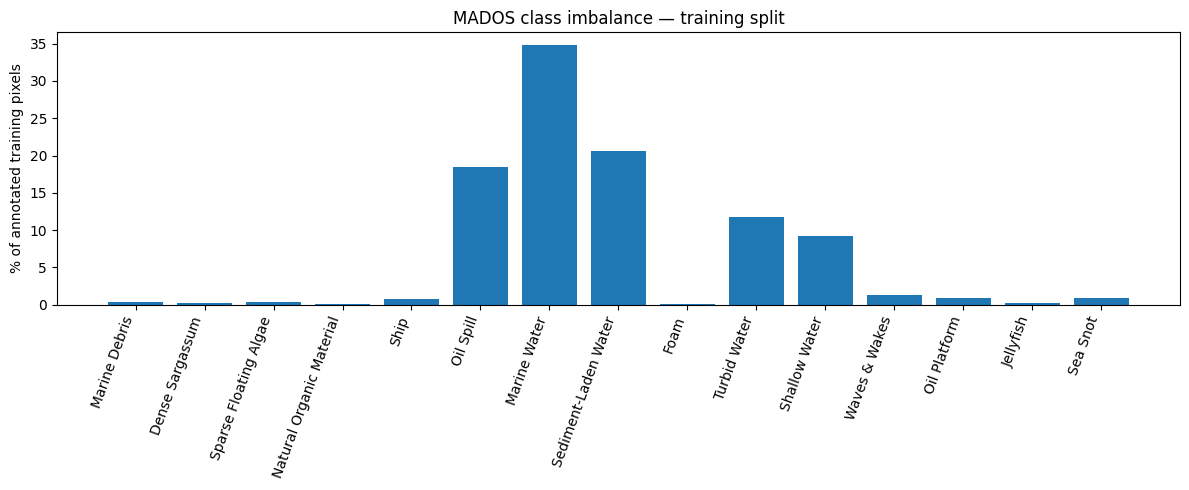

,confidence_id,pixels
0,0,81745297
1,1,771097
2,2,24017
3,3,389


,class,percent_annotated,derived_weight
0,Marine Debris,0.336139,1.301765
1,Dense Sargassum,0.241243,1.536614
2,Sparse Floating Algae,0.335877,1.302274
3,Natural Organic Material,0.141885,2.003663
4,Ship,0.775443,0.857072
5,Oil Spill,18.452080,0.175699
6,Marine Water,34.774579,0.127986
7,Sediment-Laden Water,20.638494,0.166132
8,Foam,0.061558,3.041943
9,Turbid Water,11.689660,0.220745


In [7]:

# =========================
# 6. TRAINING-SET CLASS / CONFIDENCE DISTRIBUTION
# =========================

rows = []
total_annotated = sum(class_counts[i] for i in range(1, 16))

for raw_id in range(1, 16):
    c = class_counts[raw_id]
    rows.append({
        "raw_label": raw_id,
        "train_label": raw_id - 1,
        "class": CLASS_NAMES[raw_id - 1],
        "pixels": c,
        "percent_annotated": 100 * c / max(total_annotated, 1),
    })

class_df = pd.DataFrame(rows)
display(class_df)

plt.figure(figsize=(12, 5))
plt.bar(class_df["class"], class_df["percent_annotated"])
plt.xticks(rotation=70, ha="right")
plt.ylabel("% of annotated training pixels")
plt.title("MADOS class imbalance — training split")
plt.tight_layout()
plt.show()

if confidence_counts:
    conf_df = pd.DataFrame(
        [{"confidence_id": k, "pixels": v} for k, v in sorted(confidence_counts.items())]
    )
    display(conf_df)

# Data-derived class weights.
freq = np.array([class_counts[i] for i in range(1, 16)], dtype=np.float64)
freq = freq / max(freq.sum(), 1)

# Stable inverse-sqrt weighting, normalized to mean 1.
derived_class_weights = 1.0 / np.sqrt(freq + 1e-12)
derived_class_weights /= derived_class_weights.mean()

class_df["derived_weight"] = derived_class_weights
display(class_df[["class", "percent_annotated", "derived_weight"]])

CLASS_WEIGHTS = torch.tensor(derived_class_weights, dtype=torch.float32)


In [8]:

# =========================
# 7. LOW-LEVEL RASTER LOADING
# =========================

RESAMPLING_ENUM = {
    "nearest": Resampling.nearest,
    "bilinear": Resampling.bilinear,
}[RESAMPLING]

def read_band_resampled(path: str, size=IMAGE_SIZE) -> np.ndarray:
    with rasterio.open(path) as src:
        arr = src.read(
            1,
            out_shape=(size, size),
            resampling=RESAMPLING_ENUM,
        ).astype(np.float32)
    return arr

def load_raw_sample(sample_id: str):
    s = ALL_INDEX[sample_id]

    bands = [read_band_resampled(p) for p in s["bands"]]
    image = np.stack(bands, axis=0).astype(np.float32)

    for c in range(IN_CHANNELS):
        bad = ~np.isfinite(image[c])
        if bad.any():
            image[c][bad] = BAND_MEAN[c]

    mask = read_raster_1(s["mask"]).astype(np.int64)

    if s["confidence"]:
        confidence = read_raster_1(s["confidence"]).astype(np.int64)
    else:
        confidence = np.ones_like(mask, dtype=np.int64)

    return image, mask, confidence


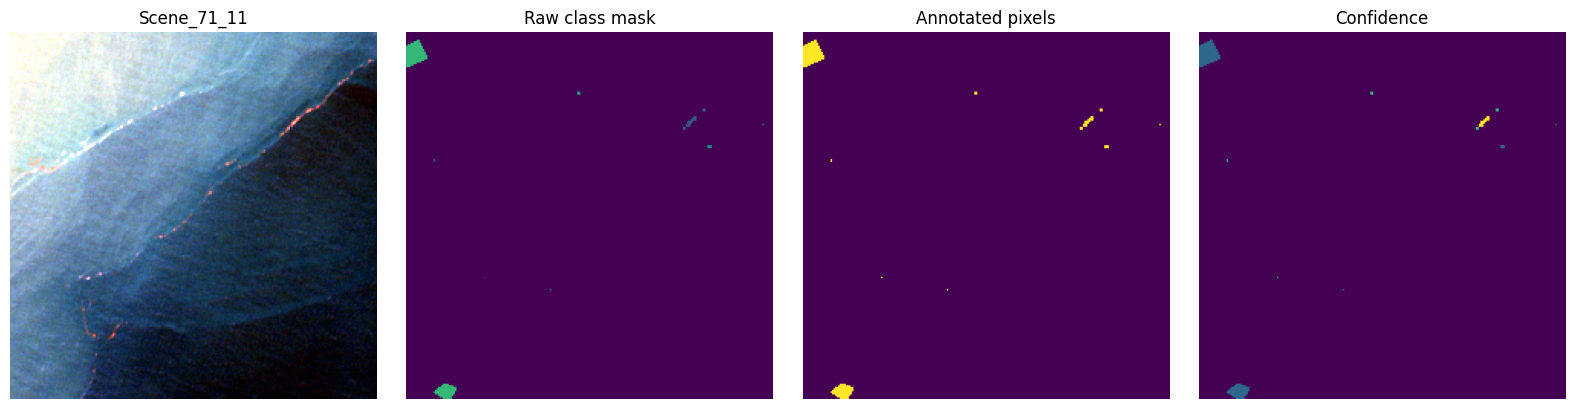

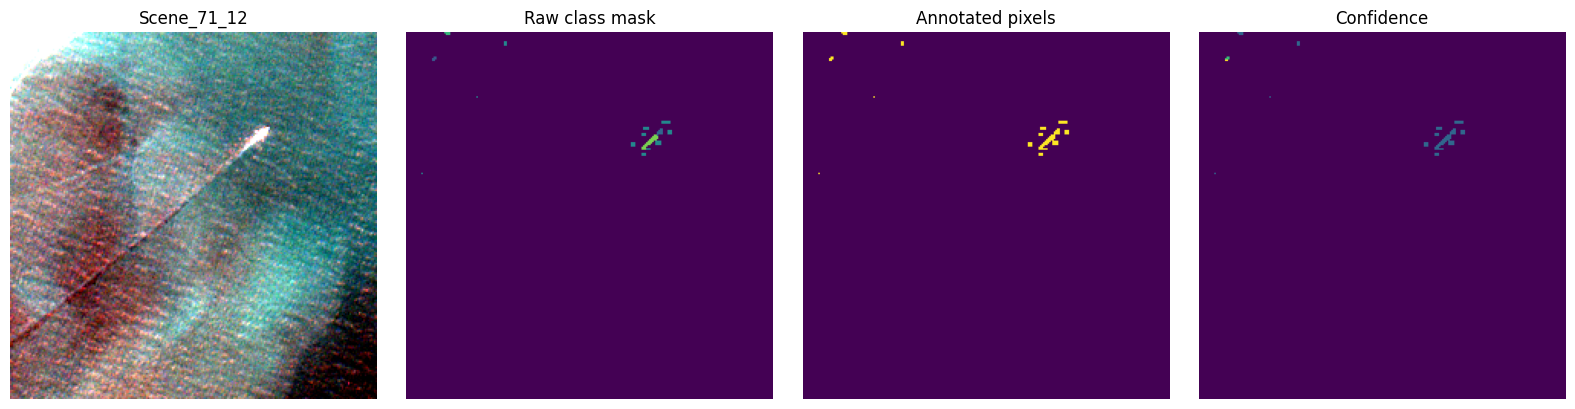

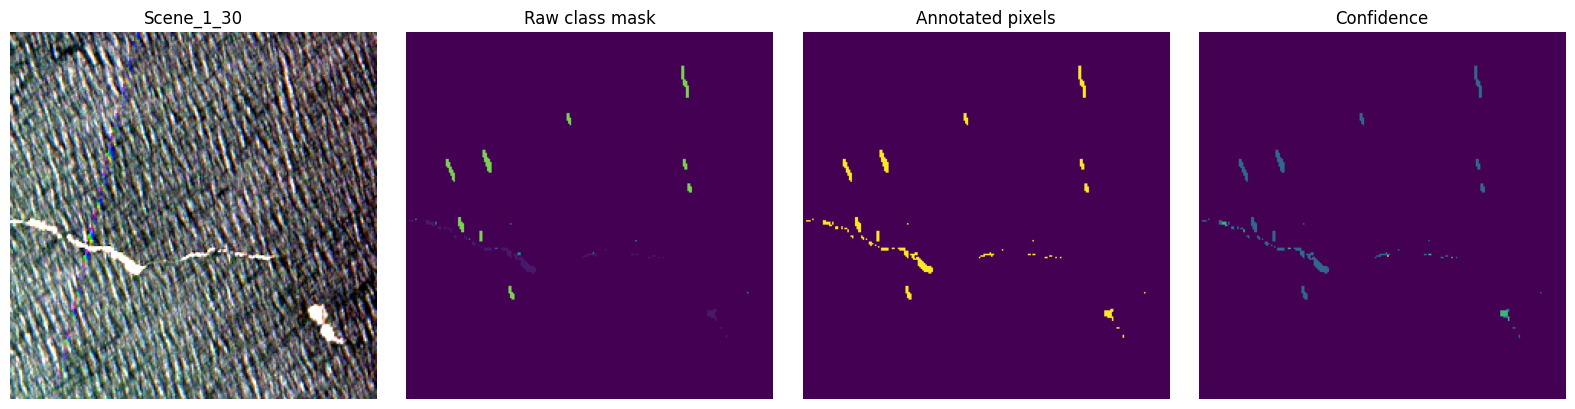

In [9]:

# =========================
# 8. VISUAL SANITY CHECK
# =========================

def robust_rgb(image: np.ndarray):
    # We do not assume band-file ordering corresponds to canonical RGB wavelengths.
    # For a visual-only sanity check, choose three central visible-ish channels
    # from the sorted wavelength stack.
    idx = [3, 2, 1] if image.shape[0] >= 4 else [0, 0, 0]
    rgb = np.stack([image[i] for i in idx], axis=-1)

    lo = np.nanpercentile(rgb, 2, axis=(0, 1), keepdims=True)
    hi = np.nanpercentile(rgb, 98, axis=(0, 1), keepdims=True)
    rgb = (rgb - lo) / np.maximum(hi - lo, 1e-6)
    return np.clip(rgb, 0, 1)

def show_sample(sample_id):
    image, mask, confidence = load_raw_sample(sample_id)

    plt.figure(figsize=(16, 4))

    plt.subplot(1, 4, 1)
    plt.imshow(robust_rgb(image))
    plt.title(sample_id)
    plt.axis("off")

    plt.subplot(1, 4, 2)
    plt.imshow(mask, vmin=0, vmax=15)
    plt.title("Raw class mask")
    plt.axis("off")

    plt.subplot(1, 4, 3)
    plt.imshow(mask > 0)
    plt.title("Annotated pixels")
    plt.axis("off")

    plt.subplot(1, 4, 4)
    plt.imshow(confidence)
    plt.title("Confidence")
    plt.axis("off")

    plt.tight_layout()
    plt.show()

# Prefer samples with several classes present.
train_audit = audit_df[audit_df["split"] == "train"].sort_values(
    ["classes_present", "annotated_pixels"], ascending=False
)
for sid in train_audit["sample_id"].head(3):
    show_sample(sid)


In [10]:

# =========================
# 9. PYTORCH DATASET
# =========================

class MADOSDataset(Dataset):
    def __init__(self, ids, augment=False):
        self.ids = list(ids)
        self.augment = augment

    def __len__(self):
        return len(self.ids)

    @staticmethod
    def augment_triplet(image, mask, confidence):
        # Satellite imagery has no canonical "up", making 90° rotations useful.
        if np.random.rand() < 0.5:
            image = np.flip(image, axis=2)
            mask = np.flip(mask, axis=1)
            confidence = np.flip(confidence, axis=1)

        if np.random.rand() < 0.5:
            image = np.flip(image, axis=1)
            mask = np.flip(mask, axis=0)
            confidence = np.flip(confidence, axis=0)

        k = np.random.randint(0, 4)
        if k:
            image = np.rot90(image, k, axes=(1, 2))
            mask = np.rot90(mask, k, axes=(0, 1))
            confidence = np.rot90(confidence, k, axes=(0, 1))

        return (
            np.ascontiguousarray(image),
            np.ascontiguousarray(mask),
            np.ascontiguousarray(confidence),
        )

    def __getitem__(self, idx):
        sample_id = self.ids[idx]
        image, raw_mask, confidence = load_raw_sample(sample_id)

        # Normalize each spectral band.
        image = (image - BAND_MEAN[:, None, None]) / BAND_STD[:, None, None]

        # MADOS:
        # raw 0 = unannotated => ignore
        # raw 1..15 => train targets 0..14
        mask = raw_mask - 1
        mask[raw_mask == 0] = IGNORE_INDEX

        if self.augment:
            image, mask, confidence = self.augment_triplet(
                image, mask, confidence
            )

        return {
            "image": torch.from_numpy(image).float(),
            "mask": torch.from_numpy(mask).long(),
            "confidence": torch.from_numpy(confidence).long(),
            "id": sample_id,
        }

train_ds = MADOSDataset(
    SPLIT_IDS["train"],
    augment=USE_AUGMENTATION,
)
val_ds = MADOSDataset(
    SPLIT_IDS["val"],
    augment=False,
)

test_ds = None
if "test" in SPLIT_IDS:
    test_ds = MADOSDataset(
        SPLIT_IDS["test"],
        augment=False,
    )

print("train:", len(train_ds))
print("val:  ", len(val_ds))
print("test: ", len(test_ds) if test_ds else "not available")


train: 1433
val:   642
test:  728


In [11]:

# =========================
# 10. RARE-CLASS-AWARE SAMPLING
# =========================

def build_sample_weights(ids):
    # Each sample receives the strongest inverse-sqrt rarity score among
    # classes actually present in its label mask.
    raw_freq = {
        raw_id: max(class_counts[raw_id], 1)
        for raw_id in range(1, 16)
    }

    inv = {
        raw_id: 1.0 / math.sqrt(raw_freq[raw_id])
        for raw_id in range(1, 16)
    }

    scores = []
    for sid in tqdm(ids, desc="Building sampler weights"):
        mask = read_raster_1(ALL_INDEX[sid]["mask"]).astype(np.int64)
        present = [int(x) for x in np.unique(mask) if 1 <= x <= 15]

        if present:
            score = max(inv[x] for x in present)
        else:
            score = min(inv.values())

        scores.append(score)

    scores = np.asarray(scores, dtype=np.float64)
    scores = scores / scores.mean()

    # Clip extremes so the sampler does not become pathological.
    scores = np.clip(scores, 0.25, 8.0)
    return scores

if USE_RARE_CLASS_SAMPLER:
    sample_weights = build_sample_weights(SPLIT_IDS["train"])
    train_sampler = WeightedRandomSampler(
        weights=torch.as_tensor(sample_weights, dtype=torch.double),
        num_samples=len(sample_weights),
        replacement=True,
    )
    shuffle_train = False
    print(
        "Rare-class sampler enabled. "
        f"weight range={sample_weights.min():.3f}..{sample_weights.max():.3f}"
    )
else:
    train_sampler = None
    shuffle_train = True
    print("Using normal random shuffling.")


Building sampler weights:   0%|          | 0/1433 [00:00<?, ?it/s]

Rare-class sampler enabled. weight range=0.250..4.269


In [12]:

# =========================
# 11. DATALOADERS
# =========================

def make_loader(dataset, batch_size, shuffle=False, sampler=None, drop_last=False):
    return DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=shuffle if sampler is None else False,
        sampler=sampler,
        num_workers=NUM_WORKERS,
        pin_memory=(DEVICE.type == "cuda"),
        persistent_workers=(NUM_WORKERS > 0),
        drop_last=drop_last,
    )

train_loader = make_loader(
    train_ds,
    BATCH_SIZE,
    shuffle=shuffle_train,
    sampler=train_sampler,
    drop_last=True,
)

val_loader = make_loader(
    val_ds,
    BATCH_SIZE,
    shuffle=False,
    drop_last=False,
)

test_loader = (
    make_loader(test_ds, BATCH_SIZE, shuffle=False, drop_last=False)
    if test_ds is not None else None
)

batch = next(iter(train_loader))
print("image:", batch["image"].shape)
print("mask: ", batch["mask"].shape)
print("conf: ", batch["confidence"].shape)

assert batch["image"].shape[1:] == (IN_CHANNELS, IMAGE_SIZE, IMAGE_SIZE)
assert batch["mask"].shape[1:] == (IMAGE_SIZE, IMAGE_SIZE)
print("✅ Dataloader smoke check passed.")


image: torch.Size([6, 11, 240, 240])
mask:  torch.Size([6, 240, 240])
conf:  torch.Size([6, 240, 240])
✅ Dataloader smoke check passed.


## 12. V3 model — SeaRel-SR-UNet

V3 preserves the entire successful V2.1 path and adds one new branch.

### Absolute branch — unchanged V2.1
- 1×1 spectral mixing: 11 → 32
- GroupNorm + GELU
- squeeze/excitation
- projection: 32 → 11
- residual add with learnable scale

### Sea-relative branch — new inductive bias

The model first reconstructs raw reflectance from the normalized input.

For each band and pixel, it estimates local context using three annular neighborhoods:

- inner 3, outer 9 pixels
- inner 7, outer 21 pixels
- inner 15, outer 41 pixels

The three context scales are combined with **learned static per-band weights**. They are not conditioned on the current image, avoiding another scene-global SE mechanism.

From the pixel spectrum `s` and context spectrum `r`, V3 constructs:

\[
\Delta = \frac{s-r}{|r|+\epsilon}
\]

\[
R = \log(s+\epsilon)-\log(r+\epsilon)
\]

and the normalized spectral angle

\[
\theta =
\frac{1}{\pi}
\cos^{-1}
\left(
\frac{s \cdot r}
{\|s\|\|r\|+\epsilon}
\right)
\]

This produces 23 LSCC channels:

- 11 relative residual channels
- 11 log-ratio channels
- 1 spectral-angle channel

A lightweight 1×1 encoder maps them back to an 11-channel correction.

The correction is `tanh` bounded and fused through per-band gates constrained to `[0, 0.5]`, initialized at only **0.05**.

In [13]:
# =========================
# 12. MODEL — V3 SeaRel-SR-UNet
# =========================

def _valid_group_count(channels, preferred=8):
    groups = min(preferred, channels)
    while channels % groups != 0:
        groups -= 1
    return groups


class SpectralSE(nn.Module):
    # Exact V2.1 absolute spectral attention block.
    def __init__(self, channels, reduction=4):
        super().__init__()
        hidden = max(channels // reduction, 8)

        self.fc1 = nn.Conv2d(channels, hidden, kernel_size=1)
        self.fc2 = nn.Conv2d(hidden, channels, kernel_size=1)

    def forward(self, x):
        gate = F.adaptive_avg_pool2d(x, output_size=1)
        gate = F.gelu(self.fc1(gate))
        gate = torch.sigmoid(self.fc2(gate))
        return x * gate


class ResidualSpectralStem(nn.Module):
    # Exact V2.1 spectral stem retained as the absolute branch.
    def __init__(
        self,
        in_channels=IN_CHANNELS,
        hidden_channels=SPECTRAL_HIDDEN,
        residual_scale_init=SPECTRAL_RESIDUAL_SCALE_INIT,
    ):
        super().__init__()

        groups = _valid_group_count(hidden_channels)

        self.mix = nn.Conv2d(
            in_channels,
            hidden_channels,
            kernel_size=1,
            bias=False,
        )
        self.norm = nn.GroupNorm(groups, hidden_channels)
        self.se = SpectralSE(hidden_channels)
        self.project = nn.Conv2d(
            hidden_channels,
            in_channels,
            kernel_size=1,
            bias=False,
        )

        self.residual_scale = nn.Parameter(
            torch.tensor(float(residual_scale_init))
        )

        nn.init.normal_(
            self.project.weight,
            mean=0.0,
            std=0.01,
        )

    def forward(self, x):
        z = self.mix(x)
        z = F.gelu(self.norm(z))
        z = self.se(z)
        z = self.project(z)

        return x + self.residual_scale * z


class SeaRelativeLSCC(nn.Module):
    # New V3 marine-context inductive bias.
    def __init__(
        self,
        in_channels=IN_CHANNELS,
        hidden_channels=LSCC_HIDDEN,
        ring_pairs=LSCC_RING_PAIRS,
        eps=LSCC_EPS,
        delta_clip=LSCC_DELTA_CLIP,
        log_clip=LSCC_LOG_RATIO_CLIP,
        gate_init=LSCC_GATE_INIT,
        gate_max=LSCC_GATE_MAX,
    ):
        super().__init__()

        self.in_channels = in_channels
        self.ring_pairs = tuple(tuple(x) for x in ring_pairs)
        self.eps = float(eps)
        self.delta_clip = float(delta_clip)
        self.log_clip = float(log_clip)
        self.gate_max = float(gate_max)

        for inner, outer in self.ring_pairs:
            if inner % 2 != 1 or outer % 2 != 1:
                raise ValueError("LSCC box sizes must be odd.")
            if not (1 <= inner < outer):
                raise ValueError(
                    f"Invalid ring pair: inner={inner}, outer={outer}"
                )

        # Published V1 normalization statistics become fixed buffers.
        self.register_buffer(
            "band_mean",
            torch.tensor(
                BAND_MEAN,
                dtype=torch.float32,
            ).view(1, in_channels, 1, 1),
        )
        self.register_buffer(
            "band_std",
            torch.tensor(
                BAND_STD,
                dtype=torch.float32,
            ).view(1, in_channels, 1, 1),
        )

        # Per-band STATIC multi-scale context weights.
        # Shape: [11 bands, 3 ring scales].
        self.scale_logits = nn.Parameter(
            torch.zeros(
                in_channels,
                len(self.ring_pairs),
                dtype=torch.float32,
            )
        )

        # LSCC = 11 delta + 11 log-ratio + 1 spectral angle.
        relative_channels = 2 * in_channels + 1

        groups = _valid_group_count(hidden_channels)

        self.encoder = nn.Sequential(
            nn.Conv2d(
                relative_channels,
                hidden_channels,
                kernel_size=1,
                bias=False,
            ),
            nn.GroupNorm(groups, hidden_channels),
            nn.GELU(),
            nn.Conv2d(
                hidden_channels,
                in_channels,
                kernel_size=1,
                bias=True,
            ),
        )

        # Initialize final projection small.
        nn.init.normal_(
            self.encoder[-1].weight,
            mean=0.0,
            std=0.01,
        )
        nn.init.zeros_(self.encoder[-1].bias)

        # Per-band bounded LSCC gates.
        # gate = gate_max * sigmoid(logit)
        normalized_init = gate_init / gate_max

        if not (0.0 < normalized_init < 1.0):
            raise ValueError(
                "LSCC_GATE_INIT must lie strictly between "
                "0 and LSCC_GATE_MAX."
            )

        init_logit = math.log(
            normalized_init / (1.0 - normalized_init)
        )

        self.gate_logits = nn.Parameter(
            torch.full(
                (in_channels,),
                float(init_logit),
                dtype=torch.float32,
            )
        )

    @staticmethod
    def _box_mean_reflect(x, kernel):
        # Separable box filtering:
        # O(K) rather than a full KxK pooling kernel.
        p = kernel // 2

        y = F.pad(
            x,
            (p, p, 0, 0),
            mode="reflect",
        )
        y = F.avg_pool2d(
            y,
            kernel_size=(1, kernel),
            stride=1,
        )

        y = F.pad(
            y,
            (0, 0, p, p),
            mode="reflect",
        )
        y = F.avg_pool2d(
            y,
            kernel_size=(kernel, 1),
            stride=1,
        )

        return y

    def _ring_mean(self, x, inner, outer):
        inner_mean = self._box_mean_reflect(
            x,
            inner,
        )
        outer_mean = self._box_mean_reflect(
            x,
            outer,
        )

        inner_area = float(inner * inner)
        outer_area = float(outer * outer)

        ring = (
            outer_mean * outer_area
            - inner_mean * inner_area
        ) / (outer_area - inner_area)

        return ring

    def ring_weights(self):
        return torch.softmax(
            self.scale_logits,
            dim=1,
        )

    def residual_gates(self):
        return self.gate_max * torch.sigmoid(
            self.gate_logits
        )

    def compute_lscc(self, normalized_x):
        # Geometric / physical features are computed in float32
        # for stable ratios and acos under AMP.
        with torch.autocast(
            device_type=normalized_x.device.type,
            enabled=False,
        ):
            x = normalized_x.float()

            raw = (
                x * self.band_std.float()
                + self.band_mean.float()
            )

            ring_refs = []

            for inner, outer in self.ring_pairs:
                ring_refs.append(
                    self._ring_mean(
                        raw,
                        inner,
                        outer,
                    )
                )

            # [B, C, S, H, W]
            stacked_refs = torch.stack(
                ring_refs,
                dim=2,
            )

            # Static learned weights, separately for each band.
            # [1, C, S, 1, 1]
            w = self.ring_weights().float()
            w = w.view(
                1,
                self.in_channels,
                len(self.ring_pairs),
                1,
                1,
            )

            reference = (
                stacked_refs * w
            ).sum(dim=2)

            delta = (
                raw - reference
            ) / (
                reference.abs()
                + self.eps
            )

            delta = delta.clamp(
                -self.delta_clip,
                self.delta_clip,
            )

            # Reflectance is nominally nonnegative.
            # Clamp only for the log operation.
            raw_pos = raw.clamp_min(
                self.eps
            )
            ref_pos = reference.clamp_min(
                self.eps
            )

            log_ratio = (
                torch.log(raw_pos)
                - torch.log(ref_pos)
            )

            log_ratio = log_ratio.clamp(
                -self.log_clip,
                self.log_clip,
            )

            # Spectral angle between pixel spectrum and
            # local context spectrum.
            dot = (
                raw * reference
            ).sum(
                dim=1,
                keepdim=True,
            )

            raw_norm = torch.linalg.vector_norm(
                raw,
                dim=1,
                keepdim=True,
            )
            ref_norm = torch.linalg.vector_norm(
                reference,
                dim=1,
                keepdim=True,
            )

            cosine = dot / (
                raw_norm
                * ref_norm
                + self.eps
            )

            cosine = cosine.clamp(
                -1.0 + 1e-6,
                1.0 - 1e-6,
            )

            angle = (
                torch.acos(cosine)
                / math.pi
            )

            lscc = torch.cat(
                [
                    delta,
                    log_ratio,
                    angle,
                ],
                dim=1,
            )

        return lscc, reference

    def forward(self, normalized_x):
        lscc, _ = self.compute_lscc(
            normalized_x
        )

        # Encoder remains trainable and AMP-friendly.
        correction = self.encoder(
            lscc
        )

        # Bound the correction in normalized feature units.
        correction = torch.tanh(
            correction
        )

        gates = self.residual_gates().view(
            1,
            self.in_channels,
            1,
            1,
        )

        return gates * correction


class SeaRelSpectralFusion(nn.Module):
    def __init__(self):
        super().__init__()

        # Winning V2.1 path.
        self.absolute_stem = ResidualSpectralStem(
            in_channels=IN_CHANNELS,
            hidden_channels=SPECTRAL_HIDDEN,
            residual_scale_init=SPECTRAL_RESIDUAL_SCALE_INIT,
        )

        # New V3 path.
        self.sea_relative = SeaRelativeLSCC(
            in_channels=IN_CHANNELS,
            hidden_channels=LSCC_HIDDEN,
        )

    def forward(self, x):
        absolute = self.absolute_stem(x)
        relative_correction = self.sea_relative(x)

        # V3 begins very close to V2.1 because the relative
        # correction is gated to ~0.05 per band initially.
        return absolute + relative_correction


class ConvBlock(nn.Module):
    # Original V1 residual GroupNorm block.
    def __init__(self, in_ch, out_ch, dropout=0.0):
        super().__init__()

        groups = _valid_group_count(out_ch)

        self.main = nn.Sequential(
            nn.Conv2d(
                in_ch,
                out_ch,
                3,
                padding=1,
                bias=False,
            ),
            nn.GroupNorm(
                groups,
                out_ch,
            ),
            nn.GELU(),

            nn.Conv2d(
                out_ch,
                out_ch,
                3,
                padding=1,
                bias=False,
            ),
            nn.GroupNorm(
                groups,
                out_ch,
            ),
            nn.GELU(),

            (
                nn.Dropout2d(dropout)
                if dropout > 0
                else nn.Identity()
            ),
        )

        self.skip = (
            nn.Conv2d(
                in_ch,
                out_ch,
                1,
                bias=False,
            )
            if in_ch != out_ch
            else nn.Identity()
        )

    def forward(self, x):
        return self.main(x) + self.skip(x)


class Down(nn.Module):
    def __init__(self, in_ch, out_ch, dropout):
        super().__init__()
        self.pool = nn.MaxPool2d(2)
        self.block = ConvBlock(
            in_ch,
            out_ch,
            dropout,
        )

    def forward(self, x):
        return self.block(
            self.pool(x)
        )


class Up(nn.Module):
    def __init__(
        self,
        in_ch,
        skip_ch,
        out_ch,
        dropout,
    ):
        super().__init__()

        self.up = nn.ConvTranspose2d(
            in_ch,
            out_ch,
            2,
            stride=2,
        )

        self.block = ConvBlock(
            out_ch + skip_ch,
            out_ch,
            dropout,
        )

    def forward(self, x, skip):
        x = self.up(x)

        if x.shape[-2:] != skip.shape[-2:]:
            x = F.interpolate(
                x,
                size=skip.shape[-2:],
                mode="bilinear",
                align_corners=False,
            )

        return self.block(
            torch.cat(
                [x, skip],
                dim=1,
            )
        )


class SeaRelSRUNet(nn.Module):
    def __init__(
        self,
        in_channels=IN_CHANNELS,
        classes=NUM_CLASSES,
        width=MODEL_WIDTH,
        dropout=DROPOUT,
    ):
        super().__init__()

        w = width

        # V3 spectral/context front-end.
        self.spectral_fusion = (
            SeaRelSpectralFusion()
        )

        # Exact V1 spatial U-Net.
        self.stem = ConvBlock(
            in_channels,
            w,
            0.0,
        )

        self.d1 = Down(
            w,
            w * 2,
            dropout,
        )
        self.d2 = Down(
            w * 2,
            w * 4,
            dropout,
        )
        self.d3 = Down(
            w * 4,
            w * 8,
            dropout,
        )
        self.d4 = Down(
            w * 8,
            w * 12,
            dropout,
        )

        self.u4 = Up(
            w * 12,
            w * 8,
            w * 8,
            dropout,
        )
        self.u3 = Up(
            w * 8,
            w * 4,
            w * 4,
            dropout,
        )
        self.u2 = Up(
            w * 4,
            w * 2,
            w * 2,
            dropout,
        )
        self.u1 = Up(
            w * 2,
            w,
            w,
            dropout,
        )

        self.head = nn.Conv2d(
            w,
            classes,
            1,
        )

    def forward(self, x):
        x = self.spectral_fusion(x)

        s0 = self.stem(x)
        s1 = self.d1(s0)
        s2 = self.d2(s1)
        s3 = self.d3(s2)
        b = self.d4(s3)

        x = self.u4(b, s3)
        x = self.u3(x, s2)
        x = self.u2(x, s1)
        x = self.u1(x, s0)

        return self.head(x)


def build_model():
    return SeaRelSRUNet(
        in_channels=IN_CHANNELS,
        classes=NUM_CLASSES,
        width=MODEL_WIDTH,
        dropout=DROPOUT,
    )


model = build_model().to(DEVICE)

params = sum(
    p.numel()
    for p in model.parameters()
)
trainable = sum(
    p.numel()
    for p in model.parameters()
    if p.requires_grad
)

lscc_params = sum(
    p.numel()
    for p in (
        model
        .spectral_fusion
        .sea_relative
        .parameters()
    )
)

print(
    f"Total parameters:     "
    f"{params/1e6:.3f} M"
)
print(
    f"Trainable parameters: "
    f"{trainable/1e6:.3f} M"
)
print(
    f"New LSCC parameters:  "
    f"{lscc_params:,}"
)

with torch.no_grad():
    dummy = torch.randn(
        1,
        IN_CHANNELS,
        IMAGE_SIZE,
        IMAGE_SIZE,
        device=DEVICE,
    )

    lscc, ref = (
        model
        .spectral_fusion
        .sea_relative
        .compute_lscc(dummy)
    )

    fused = model.spectral_fusion(
        dummy
    )
    y = model(dummy)

print("LSCC shape:        ", tuple(lscc.shape))
print("Context ref shape: ", tuple(ref.shape))
print("Fused input shape: ", tuple(fused.shape))
print("Model output:      ", tuple(y.shape))

assert lscc.shape == (
    1,
    2 * IN_CHANNELS + 1,
    IMAGE_SIZE,
    IMAGE_SIZE,
)
assert ref.shape == dummy.shape
assert fused.shape == dummy.shape
assert y.shape == (
    1,
    NUM_CLASSES,
    IMAGE_SIZE,
    IMAGE_SIZE,
)

print("✅ V3 SeaRel-SR-UNet shape check passed.")

print(
    "Initial LSCC gate mean:",
    float(
        model
        .spectral_fusion
        .sea_relative
        .residual_gates()
        .mean()
        .detach()
        .cpu()
    )
)

del dummy, lscc, ref, fused, y
gc.collect()

if DEVICE.type == "cuda":
    torch.cuda.empty_cache()

Total parameters:     14.897 M
Trainable parameters: 14.897 M
New LSCC parameters:  1,783
LSCC shape:         (1, 23, 240, 240)
Context ref shape:  (1, 11, 240, 240)
Fused input shape:  (1, 11, 240, 240)
Model output:       (1, 15, 240, 240)
✅ V3 SeaRel-SR-UNet shape check passed.
Initial LSCC gate mean: 0.05000000074505806


In [14]:

# =========================
# 13. LOSS
# =========================

CLASS_WEIGHTS_DEVICE = CLASS_WEIGHTS.to(DEVICE)

def confidence_pixel_weights(confidence, target):
    w = torch.ones_like(confidence, dtype=torch.float32)

    if USE_CONFIDENCE_WEIGHTING:
        w = torch.where(confidence == 1, torch.tensor(CONF_HIGH, device=w.device), w)
        w = torch.where(confidence == 2, torch.tensor(CONF_MEDIUM, device=w.device), w)
        w = torch.where(confidence == 3, torch.tensor(CONF_LOW, device=w.device), w)

    w = torch.where(target == IGNORE_INDEX, torch.zeros_like(w), w)
    return w

def masked_multiclass_dice(logits, target, eps=1e-6):
    valid = target != IGNORE_INDEX

    if not valid.any():
        return logits.sum() * 0.0

    safe_target = target.clone()
    safe_target[~valid] = 0

    probs = torch.softmax(logits, dim=1)
    one_hot = F.one_hot(
        safe_target,
        num_classes=NUM_CLASSES,
    ).permute(0, 3, 1, 2).float()

    valid_f = valid.unsqueeze(1).float()

    probs = probs * valid_f
    one_hot = one_hot * valid_f

    inter = (probs * one_hot).sum(dim=(0, 2, 3))
    denom = probs.sum(dim=(0, 2, 3)) + one_hot.sum(dim=(0, 2, 3))

    present = one_hot.sum(dim=(0, 2, 3)) > 0
    dice = (2 * inter + eps) / (denom + eps)

    return 1.0 - dice[present].mean()

def compute_loss(logits, target, confidence):
    ce_map = F.cross_entropy(
        logits,
        target,
        weight=CLASS_WEIGHTS_DEVICE,
        ignore_index=IGNORE_INDEX,
        reduction="none",
    )

    px_w = confidence_pixel_weights(confidence, target)

    ce = (ce_map * px_w).sum() / px_w.sum().clamp_min(1.0)
    dice = masked_multiclass_dice(logits, target)

    total = CE_WEIGHT * ce + DICE_WEIGHT * dice

    return total, {
        "ce": ce.detach(),
        "dice": dice.detach(),
    }

# Loss smoke test.
batch = next(iter(train_loader))
x = batch["image"][:2].to(DEVICE)
m = batch["mask"][:2].to(DEVICE)
c = batch["confidence"][:2].to(DEVICE)

with torch.no_grad():
    logits = model(x)
    test_loss, test_parts = compute_loss(logits, m, c)

print("Loss:", float(test_loss))
print("Parts:", {k: float(v) for k, v in test_parts.items()})
assert torch.isfinite(test_loss)
print("✅ Loss check passed.")

del x, m, c, logits
gc.collect()
if DEVICE.type == "cuda":
    torch.cuda.empty_cache()


Loss: 4.937431812286377
Parts: {'ce': 7.601703643798828, 'dice': 0.9410234689712524}
✅ Loss check passed.


In [15]:

# =========================
# 14. METRICS
# =========================

@torch.no_grad()
def update_confusion_matrix(cm, logits, target):
    pred = logits.argmax(dim=1)
    valid = target != IGNORE_INDEX

    t = target[valid].long()
    p = pred[valid].long()

    if t.numel() == 0:
        return cm

    flat = t * NUM_CLASSES + p
    hist = torch.bincount(
        flat,
        minlength=NUM_CLASSES * NUM_CLASSES
    ).reshape(NUM_CLASSES, NUM_CLASSES)

    cm += hist.cpu()
    return cm

def metrics_from_cm(cm):
    cm = cm.float()

    tp = torch.diag(cm)
    gt = cm.sum(dim=1)
    pred = cm.sum(dim=0)

    fp = pred - tp
    fn = gt - tp

    iou = tp / (tp + fp + fn).clamp_min(1)
    f1 = 2 * tp / (2 * tp + fp + fn).clamp_min(1)
    precision = tp / (tp + fp).clamp_min(1)
    recall = tp / (tp + fn).clamp_min(1)

    present = gt > 0

    per_class = {}
    for i, name in enumerate(CLASS_NAMES):
        per_class[name] = {
            "iou": float(iou[i]),
            "f1": float(f1[i]),
            "precision": float(precision[i]),
            "recall": float(recall[i]),
            "support": int(gt[i]),
        }

    return {
        "miou": float(iou[present].mean()),
        "mf1": float(f1[present].mean()),
        "mprecision": float(precision[present].mean()),
        "mrecall": float(recall[present].mean()),
        "per_class": per_class,
    }

def metrics_dataframe(metrics):
    rows = []
    for name, x in metrics["per_class"].items():
        rows.append({"class": name, **x})
    return pd.DataFrame(rows)


In [16]:

# =========================
# 15. EMA + SCHEDULER
# =========================

class ModelEMA:
    def __init__(self, model, decay=0.999):
        import copy
        self.ema = copy.deepcopy(model).eval()
        self.decay = decay

        for p in self.ema.parameters():
            p.requires_grad_(False)

    @torch.no_grad()
    def update(self, model):
        ema_state = self.ema.state_dict()
        model_state = model.state_dict()

        for k, v in ema_state.items():
            src = model_state[k].detach()

            if torch.is_floating_point(v):
                v.mul_(self.decay).add_(src, alpha=1.0 - self.decay)
            else:
                v.copy_(src)

def make_scheduler(optimizer, epochs, warmup_epochs):
    def lr_lambda(epoch):
        if epoch < warmup_epochs:
            return float(epoch + 1) / max(1, warmup_epochs)

        progress = (epoch - warmup_epochs) / max(1, epochs - warmup_epochs)
        return 0.5 * (1.0 + math.cos(math.pi * progress))

    return torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)


In [17]:

# =========================
# 16. TRAIN / EVALUATE FUNCTIONS
# =========================

def to_device(batch):
    return (
        batch["image"].to(DEVICE, non_blocking=True),
        batch["mask"].to(DEVICE, non_blocking=True),
        batch["confidence"].to(DEVICE, non_blocking=True),
    )

def autocast_context():
    return torch.autocast(
        device_type=DEVICE.type,
        dtype=torch.float16,
        enabled=(USE_AMP and DEVICE.type == "cuda"),
    )

def make_scaler():
    try:
        return torch.amp.GradScaler(
            "cuda",
            enabled=(USE_AMP and DEVICE.type == "cuda"),
        )
    except TypeError:
        return torch.cuda.amp.GradScaler(
            enabled=(USE_AMP and DEVICE.type == "cuda")
        )

def train_one_epoch(model, loader, optimizer, scaler, ema=None, desc="train"):
    model.train()

    running = defaultdict(float)
    n = 0

    pbar = tqdm(loader, desc=desc, leave=False)

    for batch in pbar:
        images, masks, confidence = to_device(batch)

        optimizer.zero_grad(set_to_none=True)

        with autocast_context():
            logits = model(images)
            loss, parts = compute_loss(logits, masks, confidence)

        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)

        if GRAD_CLIP is not None:
            nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP)

        scaler.step(optimizer)
        scaler.update()

        if ema is not None:
            ema.update(model)

        bs = images.size(0)
        n += bs

        running["loss"] += float(loss) * bs
        running["ce"] += float(parts["ce"]) * bs
        running["dice"] += float(parts["dice"]) * bs

        pbar.set_postfix(loss=f"{running['loss']/n:.4f}")

    return {k: v / max(n, 1) for k, v in running.items()}

@torch.no_grad()
def evaluate(model, loader, desc="eval"):
    model.eval()

    cm = torch.zeros((NUM_CLASSES, NUM_CLASSES), dtype=torch.int64)
    total_loss = 0.0
    n = 0

    for batch in tqdm(loader, desc=desc, leave=False):
        images, masks, confidence = to_device(batch)

        with autocast_context():
            logits = model(images)
            loss, _ = compute_loss(logits, masks, confidence)

        bs = images.size(0)
        n += bs
        total_loss += float(loss) * bs

        update_confusion_matrix(cm, logits.float(), masks)

    metrics = metrics_from_cm(cm)
    metrics["loss"] = total_loss / max(n, 1)
    return metrics

def print_summary(epoch, lr, tr, va):
    print(
        f"Epoch {epoch:03d} | lr={lr:.2e} | "
        f"train={tr['loss']:.4f} | val={va['loss']:.4f} | "
        f"mIoU={va['miou']:.4f} | mF1={va['mf1']:.4f}"
    )

    for name in [
        "Marine Debris",
        "Oil Spill",
        "Sparse Floating Algae",
        "Foam",
        "Ship",
    ]:
        x = va["per_class"][name]
        print(
            f"  {name:24s} "
            f"IoU={x['iou']:.3f} "
            f"F1={x['f1']:.3f} "
            f"P={x['precision']:.3f} "
            f"R={x['recall']:.3f}"
        )



## 17. Intentional 20-sample overfit test

This is one of the most valuable debugging tests in the notebook.

If the network **cannot nearly memorize 20 samples**, do not start an 80-epoch full run. The likely problem is in:

- image / mask alignment
- ignore-label handling
- band ordering
- normalization
- class weights
- optimizer / loss


overfit 001:   0%|          | 0/5 [00:00<?, ?it/s]

/tmp/ipykernel_23/981467044.py:62: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /pytorch/torch/csrc/autograd/generated/python_variable_methods.cpp:836.)
  running["loss"] += float(loss) * bs


overfit-eval 001:   0%|          | 0/5 [00:00<?, ?it/s]

overfit 001: loss=0.5782, mIoU=0.3572, mF1=0.4477


overfit 002:   0%|          | 0/5 [00:00<?, ?it/s]

...

overfit 039:   0%|          | 0/5 [00:00<?, ?it/s]

overfit-eval 039:   0%|          | 0/5 [00:00<?, ?it/s]

overfit 040:   0%|          | 0/5 [00:00<?, ?it/s]

overfit-eval 040:   0%|          | 0/5 [00:00<?, ?it/s]

overfit 040: loss=0.0002, mIoU=1.0000, mF1=1.0000


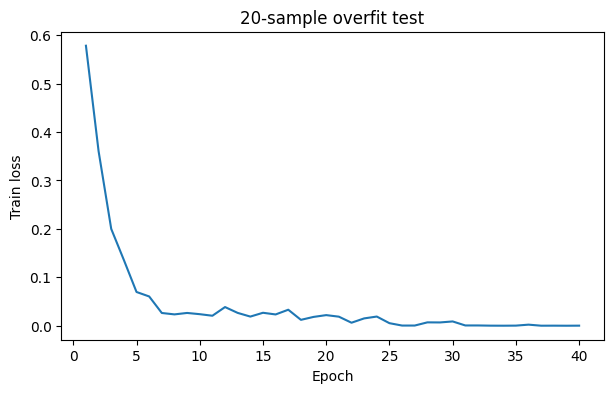

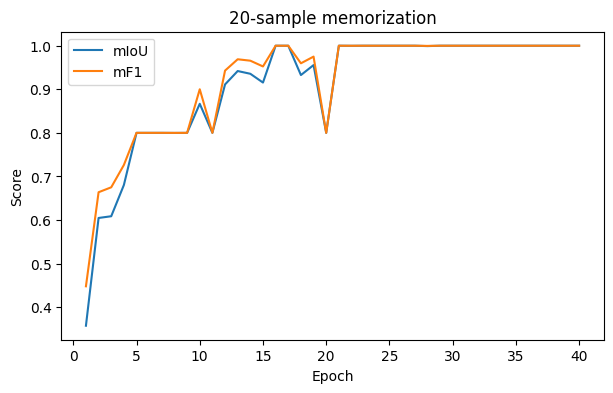

Final overfit mIoU: 1.0
Final overfit mF1:  1.0


In [18]:

# =========================
# 17. OVERFIT-20 SANITY TEST
# =========================

def run_overfit_test():
    # Prefer well-annotated / class-rich samples.
    candidate_ids = (
        audit_df[audit_df["split"] == "train"]
        .sort_values(["annotated_pixels", "classes_present"], ascending=False)
        ["sample_id"]
        .head(OVERFIT_SAMPLES)
        .tolist()
    )

    ds = MADOSDataset(candidate_ids, augment=False)
    loader = make_loader(
        ds,
        batch_size=min(4, len(ds)),
        shuffle=True,
        sampler=None,
        drop_last=False,
    )

    tiny_model = build_model().to(DEVICE)
    optimizer = torch.optim.AdamW(
        tiny_model.parameters(),
        lr=1e-3,
        weight_decay=0.0,
    )
    scaler = make_scaler()

    history = []

    for epoch in range(1, OVERFIT_EPOCHS + 1):
        tr = train_one_epoch(
            tiny_model,
            loader,
            optimizer,
            scaler,
            ema=None,
            desc=f"overfit {epoch:03d}",
        )
        ev = evaluate(
            tiny_model,
            loader,
            desc=f"overfit-eval {epoch:03d}",
        )

        history.append({
            "epoch": epoch,
            "train_loss": tr["loss"],
            "miou": ev["miou"],
            "mf1": ev["mf1"],
        })

        if epoch == 1 or epoch % 5 == 0 or epoch == OVERFIT_EPOCHS:
            print(
                f"overfit {epoch:03d}: "
                f"loss={tr['loss']:.4f}, "
                f"mIoU={ev['miou']:.4f}, "
                f"mF1={ev['mf1']:.4f}"
            )

    hist = pd.DataFrame(history)

    plt.figure(figsize=(7, 4))
    plt.plot(hist["epoch"], hist["train_loss"])
    plt.xlabel("Epoch")
    plt.ylabel("Train loss")
    plt.title("20-sample overfit test")
    plt.show()

    plt.figure(figsize=(7, 4))
    plt.plot(hist["epoch"], hist["miou"], label="mIoU")
    plt.plot(hist["epoch"], hist["mf1"], label="mF1")
    plt.xlabel("Epoch")
    plt.ylabel("Score")
    plt.title("20-sample memorization")
    plt.legend()
    plt.show()

    final = hist.iloc[-1]
    print("Final overfit mIoU:", final["miou"])
    print("Final overfit mF1: ", final["mf1"])

    del tiny_model
    gc.collect()
    if DEVICE.type == "cuda":
        torch.cuda.empty_cache()

    return hist

overfit_history = None

if RUN_OVERFIT_TEST:
    overfit_history = run_overfit_test()
else:
    print("RUN_OVERFIT_TEST=False — skipped.")


In [19]:

# =========================
# 18. FULL TRAINING
# =========================

def save_checkpoint(path, model, ema, optimizer, scheduler, scaler, epoch, best_miou):
    payload = {
        "epoch": epoch,
        "model": model.state_dict(),
        "optimizer": optimizer.state_dict(),
        "scheduler": scheduler.state_dict(),
        "scaler": scaler.state_dict(),
        "best_miou": best_miou,
        "config": {
            "seed": SEED,
            "epochs": EPOCHS,
            "batch_size": BATCH_SIZE,
            "lr": LR,
            "weight_decay": WEIGHT_DECAY,
            "model_width": MODEL_WIDTH,
            "model_name": "V3 SeaRel-SR-UNet",
            "spectral_hidden": SPECTRAL_HIDDEN,
            "spectral_residual_scale_init": SPECTRAL_RESIDUAL_SCALE_INIT,
            "lscc_ring_pairs": [list(x) for x in LSCC_RING_PAIRS],
            "lscc_hidden": LSCC_HIDDEN,
            "lscc_eps": LSCC_EPS,
            "lscc_delta_clip": LSCC_DELTA_CLIP,
            "lscc_log_ratio_clip": LSCC_LOG_RATIO_CLIP,
            "lscc_gate_init": LSCC_GATE_INIT,
            "lscc_gate_max": LSCC_GATE_MAX,

            "dropout": DROPOUT,
            "resampling": RESAMPLING,
            "use_rare_class_sampler": USE_RARE_CLASS_SAMPLER,
            "use_confidence_weighting": USE_CONFIDENCE_WEIGHTING,
            "ce_weight": CE_WEIGHT,
            "dice_weight": DICE_WEIGHT,
        }
    }

    if ema is not None:
        payload["ema"] = ema.ema.state_dict()

    torch.save(payload, path)

def run_full_training():
    model = build_model().to(DEVICE)

    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=LR,
        weight_decay=WEIGHT_DECAY,
    )

    scheduler = make_scheduler(
        optimizer,
        EPOCHS,
        WARMUP_EPOCHS,
    )

    scaler = make_scaler()

    ema = (
        ModelEMA(model, EMA_DECAY)
        if USE_EMA else None
    )

    if ema is not None:
        ema.ema.to(DEVICE)

    best_miou = -1.0
    bad_epochs = 0
    history = []

    best_path = Path(WORKDIR) / "best_v3_miou.pt"
    last_path = Path(WORKDIR) / "last_v3.pt"

    for epoch in range(1, EPOCHS + 1):
        tr = train_one_epoch(
            model,
            train_loader,
            optimizer,
            scaler,
            ema=ema,
            desc=f"train {epoch:03d}",
        )

        eval_model = ema.ema if ema is not None else model

        va = evaluate(
            eval_model,
            val_loader,
            desc=f"val {epoch:03d}",
        )

        lr = optimizer.param_groups[0]["lr"]
        print_summary(epoch, lr, tr, va)

        row = {
            "epoch": epoch,
            "lr": lr,
            "train_loss": tr["loss"],
            "train_ce": tr["ce"],
            "train_dice": tr["dice"],
            "val_loss": va["loss"],
            "val_miou": va["miou"],
            "val_mf1": va["mf1"],
            "val_mprecision": va["mprecision"],
            "val_mrecall": va["mrecall"],
        }

        history.append(row)
        pd.DataFrame(history).to_csv(
            Path(WORKDIR) / "history_v3.csv",
            index=False,
        )

        with open(Path(WORKDIR) / "history_v3.json", "w") as f:
            json.dump(history, f, indent=2)

        save_checkpoint(
            last_path,
            model,
            ema,
            optimizer,
            scheduler,
            scaler,
            epoch,
            best_miou,
        )

        if va["miou"] > best_miou:
            best_miou = va["miou"]
            bad_epochs = 0

            save_checkpoint(
                best_path,
                model,
                ema,
                optimizer,
                scheduler,
                scaler,
                epoch,
                best_miou,
            )

            with open(Path(WORKDIR) / "best_v3_val_metrics.json", "w") as f:
                json.dump(va, f, indent=2)

            print(f"  ✅ New best mIoU: {best_miou:.4f}")

        else:
            bad_epochs += 1

        scheduler.step()

        if bad_epochs >= EARLY_STOPPING_PATIENCE:
            print(
                f"Early stopping after {bad_epochs} epochs "
                "without mIoU improvement."
            )
            break

    return model, ema, pd.DataFrame(history)

trained_model = None
ema_model = None
history_df = None

if RUN_FULL_TRAINING:
    trained_model, ema_model, history_df = run_full_training()
else:
    print("RUN_FULL_TRAINING=False — skipped.")


train 001:   0%|          | 0/238 [00:00<?, ?it/s]

val 001:   0%|          | 0/107 [00:00<?, ?it/s]

Epoch 001 | lr=6.00e-05 | train=1.2024 | val=1.1674 | mIoU=0.0856 | mF1=0.1279
  Marine Debris            IoU=0.000 F1=0.000 P=0.000 R=0.000
  Oil Spill                IoU=0.071 F1=0.132 P=0.609 R=0.074
  Sparse Floating Algae    IoU=0.009 F1=0.019 P=0.010 R=0.193
  Foam                     IoU=0.002 F1=0.004 P=0.002 R=0.027
  Ship                     IoU=0.029 F1=0.056 P=0.032 R=0.195
  ✅ New best mIoU: 0.0856


train 002:   0%|          | 0/238 [00:00<?, ?it/s]

val 002:   0%|          | 0/107 [00:00<?, ?it/s]

...

val 037:   0%|          | 0/107 [00:00<?, ?it/s]

Epoch 037 | lr=1.90e-04 | train=0.0567 | val=0.4157 | mIoU=0.6778 | mF1=0.7616
  Marine Debris            IoU=0.786 F1=0.880 P=0.858 R=0.903
  Oil Spill                IoU=0.672 F1=0.804 P=0.848 R=0.764
  Sparse Floating Algae    IoU=0.193 F1=0.323 P=0.203 R=0.797
  Foam                     IoU=0.792 F1=0.884 P=0.826 R=0.951
  Ship                     IoU=0.589 F1=0.741 P=0.646 R=0.868


train 038:   0%|          | 0/238 [00:00<?, ?it/s]

val 038:   0%|          | 0/107 [00:00<?, ?it/s]

Epoch 038 | lr=1.84e-04 | train=0.0617 | val=0.4215 | mIoU=0.6812 | mF1=0.7643
  Marine Debris            IoU=0.795 F1=0.886 P=0.862 R=0.910
  Oil Spill                IoU=0.691 F1=0.817 P=0.866 R=0.773
  Sparse Floating Algae    IoU=0.187 F1=0.315 P=0.196 R=0.797
  Foam                     IoU=0.796 F1=0.886 P=0.830 R=0.951
  Ship                     IoU=0.588 F1=0.741 P=0.647 R=0.867
Early stopping after 15 epochs without mIoU improvement.


,epoch,lr,train_loss,train_ce,train_dice,val_loss,val_miou,val_mf1,val_mprecision,val_mrecall
33,34,0.000208,0.068974,0.061406,0.080326,0.383030,0.670825,0.755985,0.748953,0.809457
34,35,0.000202,0.068845,0.062056,0.079029,0.390255,0.673616,0.757706,0.749054,0.809665
35,36,0.000196,0.053669,0.044885,0.066845,0.403796,0.674747,0.758602,0.748965,0.809946
36,37,0.000190,0.056715,0.047832,0.070039,0.415684,0.677830,0.761624,0.751101,0.811609
37,38,0.000184,0.061734,0.060033,0.064285,0.421495,0.681243,0.764317,0.756567,0.813049


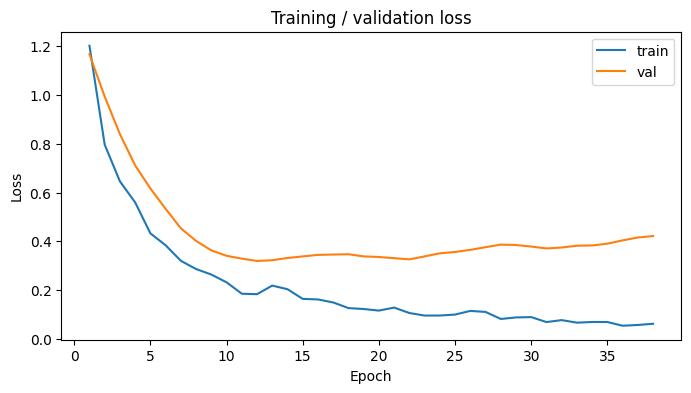

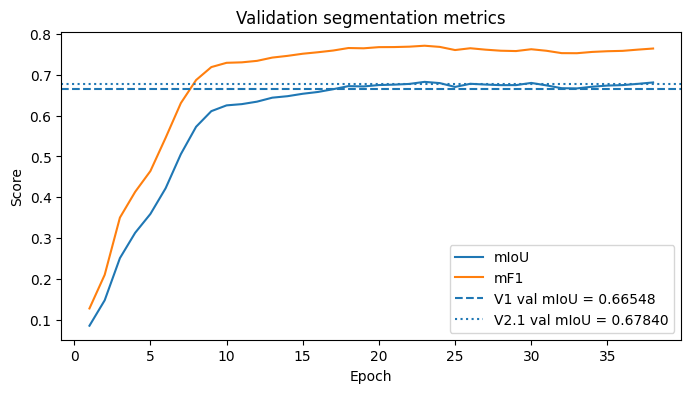

In [20]:

# =========================
# 19. TRAINING CURVES
# =========================

if history_df is not None and len(history_df):
    display(history_df.tail())

    plt.figure(figsize=(8, 4))
    plt.plot(history_df["epoch"], history_df["train_loss"], label="train")
    plt.plot(history_df["epoch"], history_df["val_loss"], label="val")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("Training / validation loss")
    plt.legend()
    plt.show()

    plt.figure(figsize=(8, 4))
    plt.plot(history_df["epoch"], history_df["val_miou"], label="mIoU")
    plt.plot(history_df["epoch"], history_df["val_mf1"], label="mF1")
    plt.axhline(
        0.6654805993661285,
        linestyle="--",
        label="V1 val mIoU = 0.66548",
    )
    plt.axhline(
        0.6784029603004456,
        linestyle=":",
        label="V2.1 val mIoU = 0.67840",
    )
    plt.xlabel("Epoch")
    plt.ylabel("Score")
    plt.title("Validation segmentation metrics")
    plt.legend()
    plt.show()


In [21]:

# =========================
# 20. RESTORE BEST CHECKPOINT
# =========================

BEST_CKPT = Path(WORKDIR) / "best_v3_miou.pt"

assert BEST_CKPT.exists(), (
    f"{BEST_CKPT} does not exist. "
    "Run full training first or place a compatible checkpoint there."
)

ckpt = torch.load(BEST_CKPT, map_location=DEVICE)

best_model = build_model().to(DEVICE)

# Use EMA weights when available because validation was performed on EMA.
if "ema" in ckpt:
    best_model.load_state_dict(ckpt["ema"])
    print("Loaded EMA weights.")
else:
    best_model.load_state_dict(ckpt["model"])
    print("Loaded raw model weights.")

best_model.eval()

print("Best checkpoint epoch:", ckpt["epoch"])
print("Best validation mIoU saved:", ckpt["best_miou"])


Loaded EMA weights.
Best checkpoint epoch: 23
Best validation mIoU saved: 0.6826989650726318


best V3 validation:   0%|          | 0/107 [00:00<?, ?it/s]

V3 validation mIoU: 0.6826989650726318
V3 validation mF1:  0.771173894405365

Δ mIoU vs V1:   0.01721836570650337
Δ mIoU vs V2.1: 0.004296004772186279
Δ mF1 vs V2.1:  -0.003246128559112549


,class,iou,f1,precision,recall,support
3,Natural Organic Material,0.000000,0.000000,0.000000,0.000000,95
11,Waves & Wakes,0.240652,0.387944,0.258629,0.775888,3998
2,Sparse Floating Algae,0.445365,0.616267,0.457785,0.942584,627
4,Ship,0.558876,0.717024,0.628244,0.835027,3740
12,Oil Platform,0.578547,0.733012,0.824260,0.659954,3923
5,Oil Spill,0.655313,0.791769,0.814413,0.770350,42456
10,Shallow Water,0.773540,0.872312,0.974493,0.789525,40019
6,Marine Water,0.779442,0.876052,0.877023,0.875084,92294
0,Marine Debris,0.795994,0.886411,0.852264,0.923408,1162
8,Foam,0.839713,0.912874,0.877500,0.951219,369


validation confusion matrix:   0%|          | 0/107 [00:00<?, ?it/s]

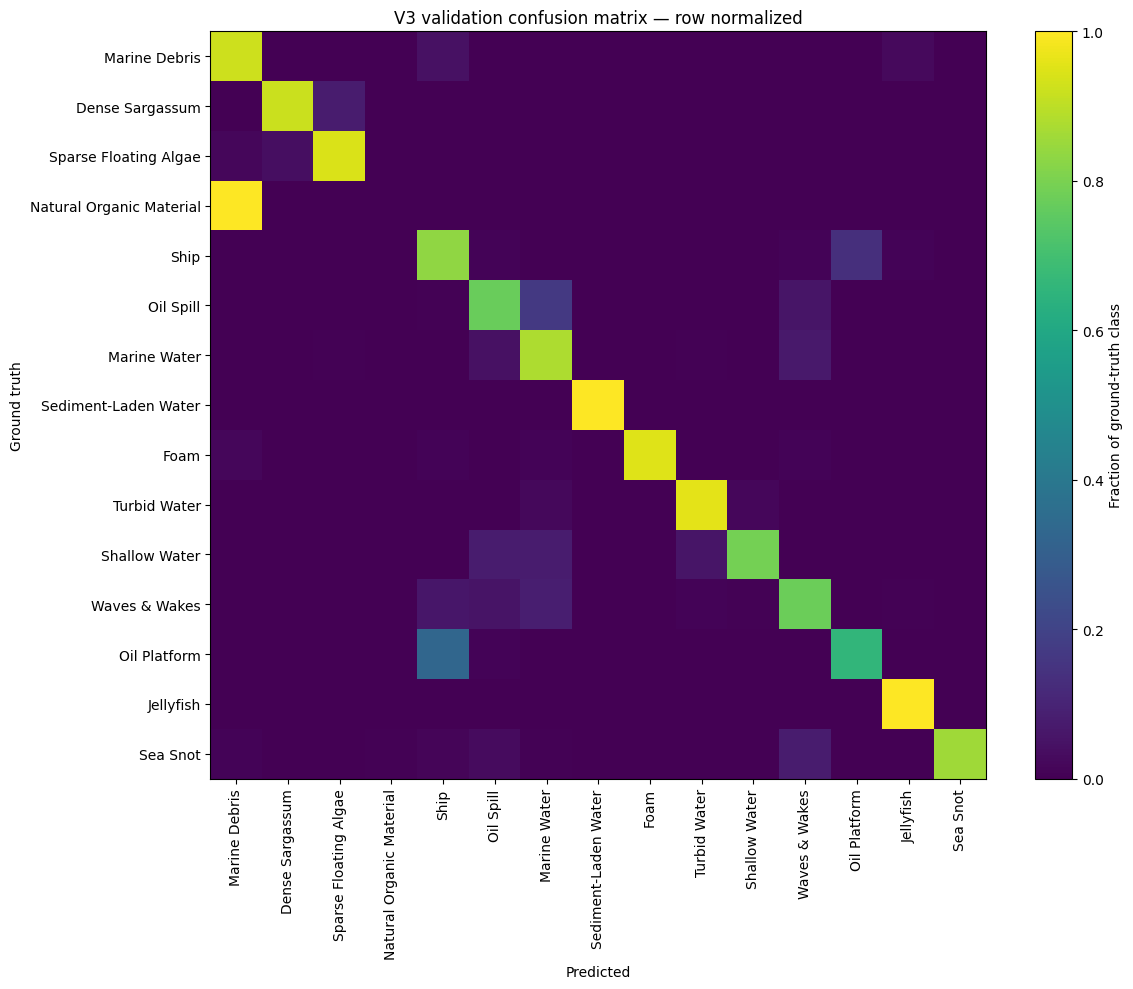

,ground_truth,predicted,pixels,fraction_of_gt
13,Natural Organic Material,Marine Debris,95,1.000000
69,Oil Platform,Ship,1300,0.331379
24,Oil Spill,Marine Water,7071,0.166549
20,Ship,Oil Platform,500,0.133690
61,Waves & Wakes,Marine Water,328,0.082041
76,Sea Snot,Waves & Wakes,207,0.076610
54,Shallow Water,Marine Water,3058,0.076414
7,Dense Sargassum,Sparse Floating Algae,89,0.076264
53,Shallow Water,Oil Spill,2997,0.074889
39,Marine Water,Waves & Wakes,6246,0.067675



Sparse Floating Algae false-positive sources:


,predicted_class,actual_source,pixels,fraction_of_all_FP
10,Sparse Floating Algae,Marine Water,554,0.791429
8,Sparse Floating Algae,Dense Sargassum,89,0.127143
9,Sparse Floating Algae,Oil Spill,57,0.081429



Waves & Wakes false-positive sources:


,predicted_class,actual_source,pixels,fraction_of_all_FP
64,Waves & Wakes,Marine Water,6246,0.702429
63,Waves & Wakes,Oil Spill,2371,0.266644
68,Waves & Wakes,Sea Snot,207,0.023279
62,Waves & Wakes,Ship,33,0.003711
66,Waves & Wakes,Turbid Water,21,0.002362
67,Waves & Wakes,Shallow Water,9,0.001012
65,Waves & Wakes,Foam,3,0.000337
61,Waves & Wakes,Marine Debris,2,0.000225



V2.1 absolute spectral residual scale: 0.2605805993080139
Mean learned LSCC gate: 0.05693359673023224


,band_wavelength,lscc_gate,weight_3-9px,weight_7-21px,weight_15-41px
0,442,0.053489,0.305783,0.332282,0.361935
1,492,0.063623,0.335672,0.306817,0.357511
2,559,0.058045,0.328211,0.320911,0.350878
3,665,0.058979,0.329808,0.324766,0.345426
4,704,0.054141,0.366808,0.325367,0.307825
5,739,0.056012,0.331462,0.355250,0.313288
6,780,0.058110,0.342490,0.351161,0.306349
7,833,0.054920,0.351463,0.315157,0.333380
8,864,0.055838,0.350722,0.331718,0.317560
9,1610,0.056705,0.323009,0.313495,0.363496


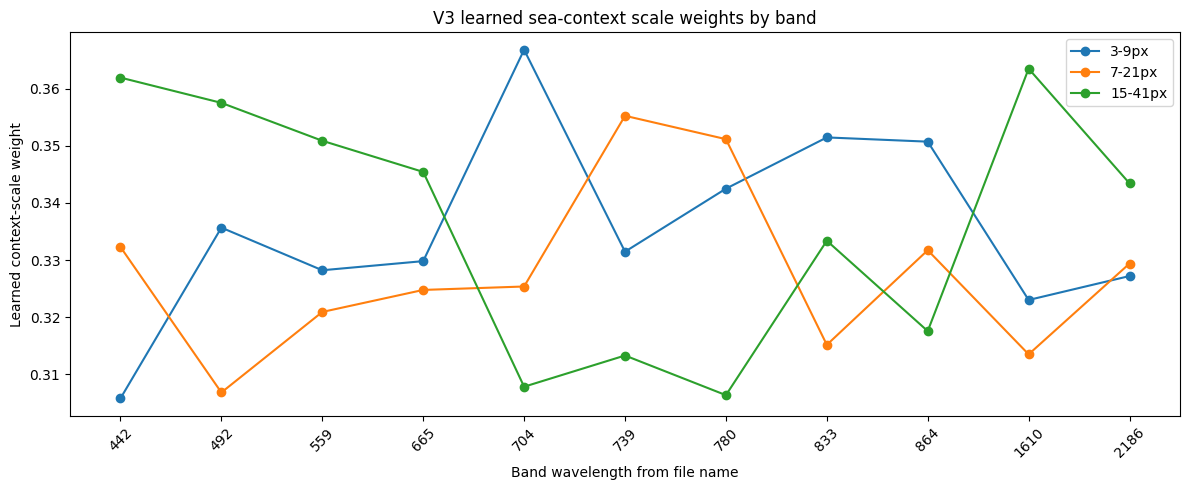

In [22]:
# =========================
# 21. FINAL V3 VALIDATION REPORT
#     + LSCC DIAGNOSTICS
# =========================

V1_VAL_MIOU = 0.6654805993661285
V1_VAL_MF1 = 0.7621197336663802

V21_VAL_MIOU = 0.6784029603004456
V21_VAL_MF1 = 0.7744200229644775

final_val_metrics = evaluate(
    best_model,
    val_loader,
    desc="best V3 validation",
)

print("V3 validation mIoU:", final_val_metrics["miou"])
print("V3 validation mF1: ", final_val_metrics["mf1"])
print()

print(
    "Δ mIoU vs V1:  ",
    final_val_metrics["miou"]
    - V1_VAL_MIOU
)
print(
    "Δ mIoU vs V2.1:",
    final_val_metrics["miou"]
    - V21_VAL_MIOU
)
print(
    "Δ mF1 vs V2.1: ",
    final_val_metrics["mf1"]
    - V21_VAL_MF1
)

val_class_df = metrics_dataframe(
    final_val_metrics
)

display(
    val_class_df.sort_values(
        "iou"
    )
)

val_class_df.to_csv(
    Path(WORKDIR)
    / "validation_per_class_v3.csv",
    index=False,
)

with open(
    Path(WORKDIR)
    / "validation_metrics_v3.json",
    "w",
) as f:
    json.dump(
        final_val_metrics,
        f,
        indent=2,
    )


# ---------------------------------
# Full validation confusion matrix
# ---------------------------------

@torch.no_grad()
def collect_confusion_matrix(
    model,
    loader,
):
    model.eval()

    cm = torch.zeros(
        (
            NUM_CLASSES,
            NUM_CLASSES,
        ),
        dtype=torch.int64,
    )

    for batch in tqdm(
        loader,
        desc="validation confusion matrix",
        leave=False,
    ):
        images = batch["image"].to(
            DEVICE,
            non_blocking=True,
        )
        masks = batch["mask"].to(
            DEVICE,
            non_blocking=True,
        )

        with autocast_context():
            logits = model(
                images
            )

        update_confusion_matrix(
            cm,
            logits.float(),
            masks,
        )

    return cm


val_cm = collect_confusion_matrix(
    best_model,
    val_loader,
)

np.save(
    Path(WORKDIR)
    / "validation_confusion_v3.npy",
    val_cm.numpy(),
)

cm_np = val_cm.numpy().astype(
    np.float64
)

cm_norm = cm_np / np.maximum(
    cm_np.sum(
        axis=1,
        keepdims=True,
    ),
    1,
)

plt.figure(
    figsize=(12, 10)
)
plt.imshow(
    cm_norm,
    aspect="auto",
)
plt.colorbar(
    label=(
        "Fraction of "
        "ground-truth class"
    )
)
plt.xticks(
    range(NUM_CLASSES),
    CLASS_NAMES,
    rotation=90,
)
plt.yticks(
    range(NUM_CLASSES),
    CLASS_NAMES,
)
plt.xlabel("Predicted")
plt.ylabel("Ground truth")
plt.title(
    "V3 validation confusion matrix "
    "— row normalized"
)
plt.tight_layout()
plt.show()


# ---------------------------------
# Top off-diagonal confusions
# ---------------------------------

confusion_rows = []

for gt in range(NUM_CLASSES):
    row_total = max(
        cm_np[gt].sum(),
        1,
    )

    for pred in range(NUM_CLASSES):
        if gt == pred:
            continue

        count = int(
            cm_np[gt, pred]
        )

        if count:
            confusion_rows.append({
                "ground_truth": (
                    CLASS_NAMES[gt]
                ),
                "predicted": (
                    CLASS_NAMES[pred]
                ),
                "pixels": count,
                "fraction_of_gt": (
                    count / row_total
                ),
            })

top_confusions_df = (
    pd.DataFrame(
        confusion_rows
    )
    .sort_values(
        [
            "fraction_of_gt",
            "pixels",
        ],
        ascending=False,
    )
    .head(40)
)

display(
    top_confusions_df
)

top_confusions_df.to_csv(
    Path(WORKDIR)
    / "top_confusions_v3.csv",
    index=False,
)


# ---------------------------------
# Column-wise false-positive sources
# ---------------------------------

fp_rows = []

for pred in range(NUM_CLASSES):
    total_fp = (
        cm_np[:, pred].sum()
        - cm_np[pred, pred]
    )

    if total_fp <= 0:
        continue

    for gt in range(NUM_CLASSES):
        if gt == pred:
            continue

        count = int(
            cm_np[gt, pred]
        )

        if count > 0:
            fp_rows.append({
                "predicted_class": (
                    CLASS_NAMES[pred]
                ),
                "actual_source": (
                    CLASS_NAMES[gt]
                ),
                "pixels": count,
                "fraction_of_all_FP": (
                    count / total_fp
                ),
            })

false_positive_sources_df = (
    pd.DataFrame(fp_rows)
    .sort_values(
        [
            "predicted_class",
            "fraction_of_all_FP",
        ],
        ascending=[True, False],
    )
)

false_positive_sources_df.to_csv(
    Path(WORKDIR)
    / "false_positive_sources_v3.csv",
    index=False,
)

print(
    "\nSparse Floating Algae "
    "false-positive sources:"
)
display(
    false_positive_sources_df[
        false_positive_sources_df[
            "predicted_class"
        ]
        == "Sparse Floating Algae"
    ].head(15)
)

print(
    "\nWaves & Wakes "
    "false-positive sources:"
)
display(
    false_positive_sources_df[
        false_positive_sources_df[
            "predicted_class"
        ]
        == "Waves & Wakes"
    ].head(15)
)


# ---------------------------------
# Learned LSCC parameters
# ---------------------------------

lscc_module = (
    best_model
    .spectral_fusion
    .sea_relative
)

ring_weights = (
    lscc_module
    .ring_weights()
    .detach()
    .cpu()
    .numpy()
)

lscc_gates = (
    lscc_module
    .residual_gates()
    .detach()
    .cpu()
    .numpy()
)

absolute_scale = float(
    best_model
    .spectral_fusion
    .absolute_stem
    .residual_scale
    .detach()
    .cpu()
)

# Derive wavelength labels directly from the actual dataset files.
example_sid = SPLIT_IDS["train"][0]
band_labels = [
    str(
        band_number(p)
    )
    for p in ALL_INDEX[
        example_sid
    ]["bands"]
]

ring_names = [
    f"{inner}-{outer}px"
    for inner, outer
    in LSCC_RING_PAIRS
]

lscc_parameter_df = pd.DataFrame({
    "band_wavelength": band_labels,
    "lscc_gate": lscc_gates,
})

for i, ring_name in enumerate(
    ring_names
):
    lscc_parameter_df[
        f"weight_{ring_name}"
    ] = ring_weights[:, i]

print(
    "\nV2.1 absolute spectral "
    "residual scale:",
    absolute_scale
)

print(
    "Mean learned LSCC gate:",
    float(
        lscc_gates.mean()
    )
)

display(
    lscc_parameter_df
)

lscc_parameter_df.to_csv(
    Path(WORKDIR)
    / "learned_lscc_parameters_v3.csv",
    index=False,
)


# Ring-weight visualization.
plt.figure(
    figsize=(12, 5)
)

xpos = np.arange(
    len(band_labels)
)

for i, ring_name in enumerate(
    ring_names
):
    plt.plot(
        xpos,
        ring_weights[:, i],
        marker="o",
        label=ring_name,
    )

plt.xticks(
    xpos,
    band_labels,
    rotation=45,
)
plt.xlabel(
    "Band wavelength from file name"
)
plt.ylabel(
    "Learned context-scale weight"
)
plt.title(
    "V3 learned sea-context "
    "scale weights by band"
)
plt.legend()
plt.tight_layout()
plt.show()

In [23]:

# =========================
# 22. TEST-TIME AUGMENTATION INFERENCE
# =========================

@torch.no_grad()
def tta_logits(model, x):
    # Identity.
    preds = [model(x)]

    # Horizontal flip.
    xf = torch.flip(x, dims=[3])
    yf = model(xf)
    preds.append(torch.flip(yf, dims=[3]))

    # Vertical flip.
    xf = torch.flip(x, dims=[2])
    yf = model(xf)
    preds.append(torch.flip(yf, dims=[2]))

    # Both flips.
    xf = torch.flip(x, dims=[2, 3])
    yf = model(xf)
    preds.append(torch.flip(yf, dims=[2, 3]))

    return torch.stack(preds).mean(dim=0)

@torch.no_grad()
def evaluate_tta(model, loader, desc="tta-eval"):
    model.eval()
    cm = torch.zeros((NUM_CLASSES, NUM_CLASSES), dtype=torch.int64)

    for batch in tqdm(loader, desc=desc, leave=False):
        images = batch["image"].to(DEVICE, non_blocking=True)
        masks = batch["mask"].to(DEVICE, non_blocking=True)

        with autocast_context():
            logits = tta_logits(model, images)

        update_confusion_matrix(cm, logits.float(), masks)

    return metrics_from_cm(cm)


In [24]:
# =========================
# 23. OPTIONAL FINAL TEST EVALUATION
# =========================

final_test_metrics = None

if not RUN_FINAL_TEST:
    print(
        "RUN_FINAL_TEST=False — "
        "test set intentionally untouched. "
        "Select V3 using validation first."
    )

elif test_loader is None:
    print(
        "No official test split was found; "
        "skipped."
    )

else:
    if USE_TTA_ON_TEST:
        final_test_metrics = evaluate_tta(
            best_model,
            test_loader,
            desc="V3 test + TTA",
        )
    else:
        final_test_metrics = evaluate(
            best_model,
            test_loader,
            desc="V3 test",
        )

    print(
        "V3 Test mIoU:",
        final_test_metrics["miou"]
    )
    print(
        "V3 Test mF1: ",
        final_test_metrics["mf1"]
    )

    test_class_df = metrics_dataframe(
        final_test_metrics
    )

    display(
        test_class_df.sort_values(
            "iou"
        )
    )

    test_class_df.to_csv(
        Path(WORKDIR)
        / "test_per_class_v3.csv",
        index=False,
    )

    with open(
        Path(WORKDIR)
        / "test_metrics_v3.json",
        "w",
    ) as f:
        json.dump(
            final_test_metrics,
            f,
            indent=2,
        )

RUN_FINAL_TEST=False — test set intentionally untouched. Select V3 using validation first.


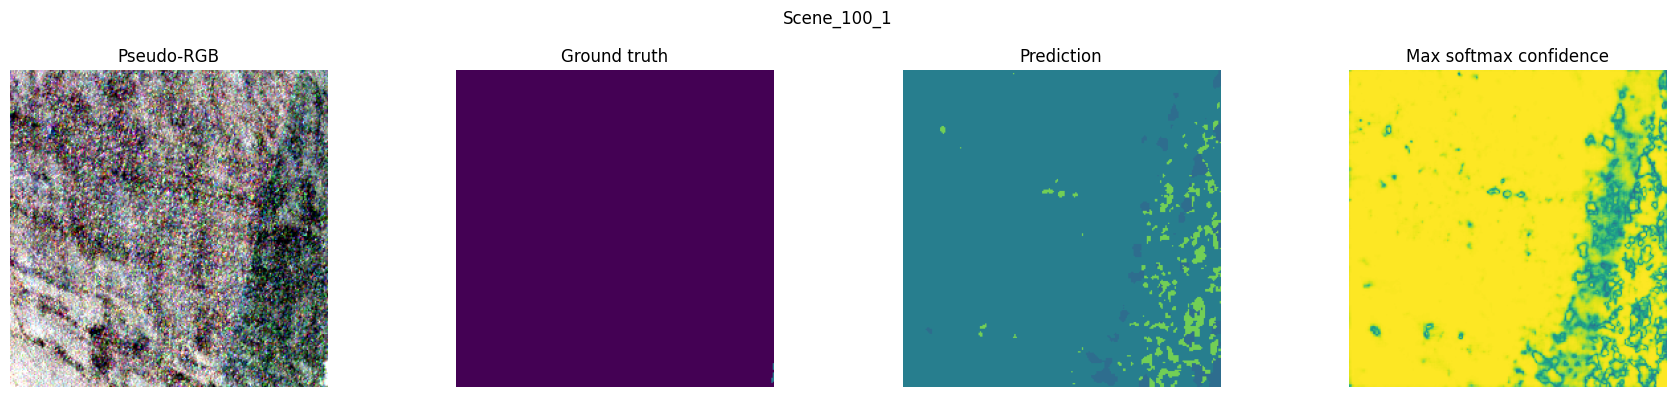

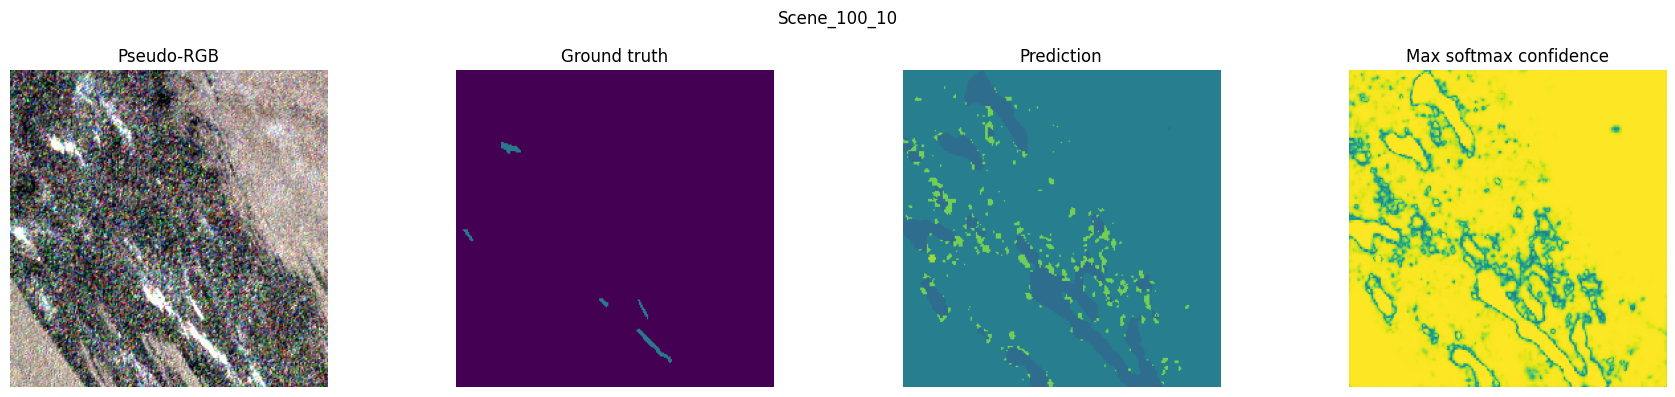

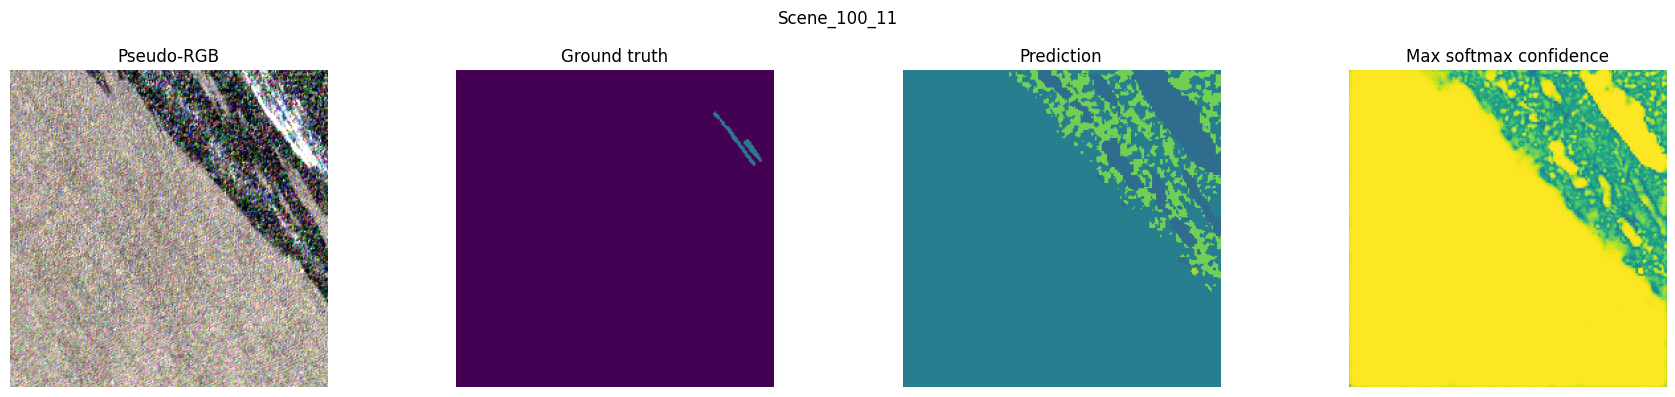

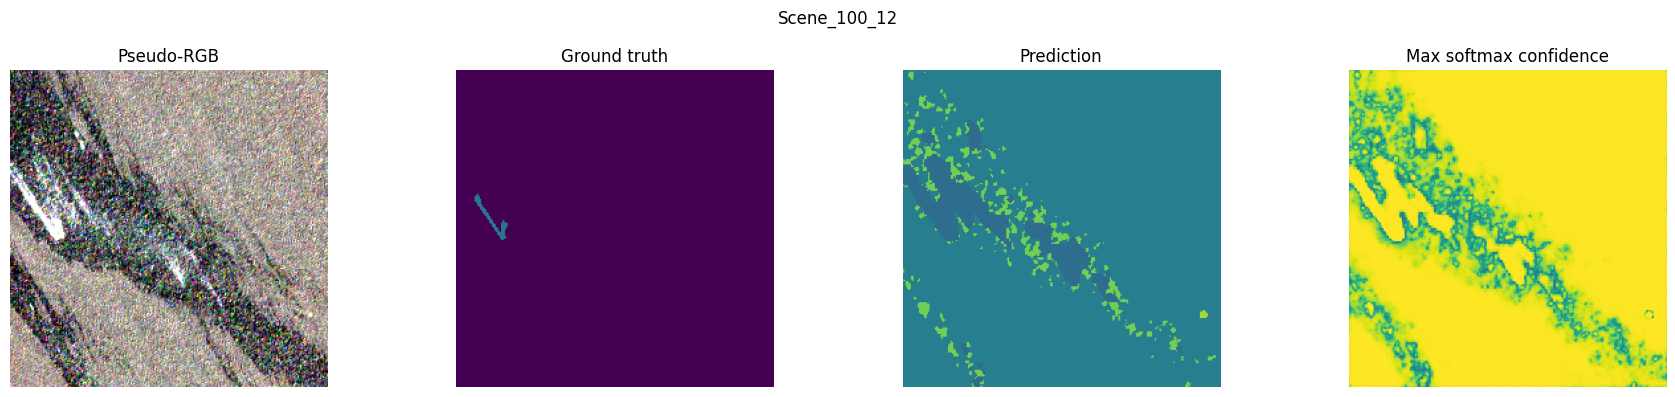

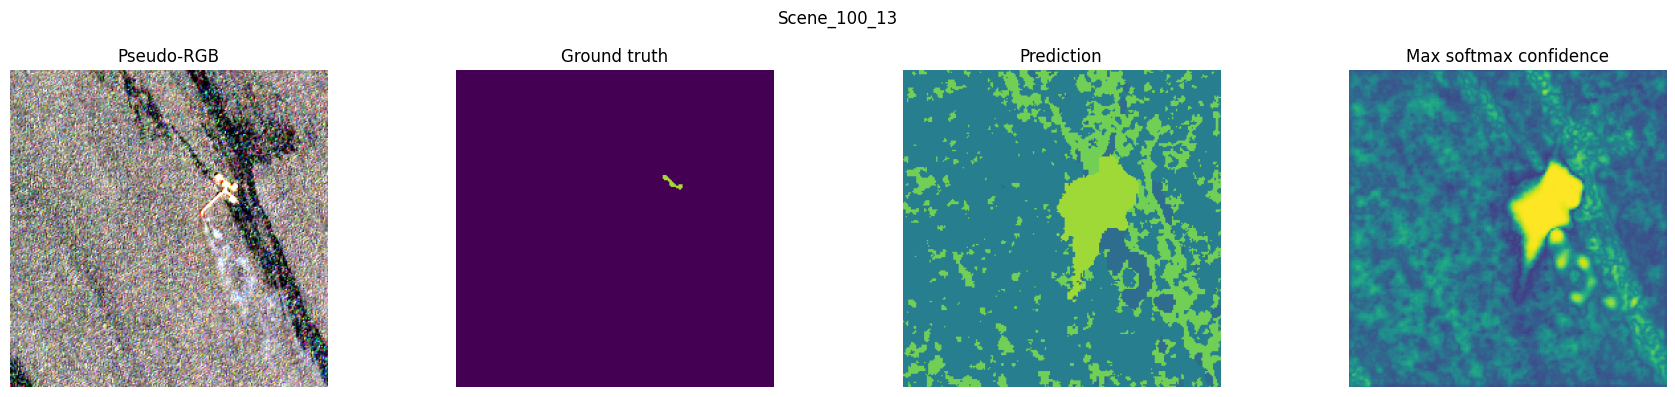

In [25]:

# =========================
# 24. V3 PREDICTION VISUALIZATION
# =========================

@torch.no_grad()
def predict_one(sample_id, use_tta=True):
    ds = MADOSDataset([sample_id], augment=False)
    item = ds[0]

    x = item["image"].unsqueeze(0).to(DEVICE)

    with autocast_context():
        logits = (
            tta_logits(best_model, x)
            if use_tta
            else best_model(x)
        )

    probs = torch.softmax(logits.float(), dim=1)
    conf, pred = probs.max(dim=1)

    pred = pred[0].cpu().numpy()
    conf = conf[0].cpu().numpy()

    raw_image, raw_mask, _ = load_raw_sample(sample_id)

    return raw_image, raw_mask, pred, conf

def show_prediction(sample_id):
    raw_image, raw_mask, pred, pred_conf = predict_one(
        sample_id,
        use_tta=USE_TTA_ON_TEST,
    )

    # Convert model class 0..14 back to raw-style 1..15 for display.
    pred_raw = pred + 1

    plt.figure(figsize=(18, 4))

    plt.subplot(1, 4, 1)
    plt.imshow(robust_rgb(raw_image))
    plt.title("Pseudo-RGB")
    plt.axis("off")

    plt.subplot(1, 4, 2)
    plt.imshow(raw_mask, vmin=0, vmax=15)
    plt.title("Ground truth")
    plt.axis("off")

    plt.subplot(1, 4, 3)
    plt.imshow(pred_raw, vmin=1, vmax=15)
    plt.title("Prediction")
    plt.axis("off")

    plt.subplot(1, 4, 4)
    plt.imshow(pred_conf, vmin=0, vmax=1)
    plt.title("Max softmax confidence")
    plt.axis("off")

    plt.suptitle(sample_id)
    plt.tight_layout()
    plt.show()

viz_ids = (
    SPLIT_IDS["test"][:5]
    if RUN_FINAL_TEST and "test" in SPLIT_IDS
    else SPLIT_IDS["val"][:5]
)

for sid in viz_ids:
    show_prediction(sid)


In [26]:

# =========================
# 25. EXPORT V3 PREDICTIONS
# =========================

@torch.no_grad()
def export_predictions(model, dataset, out_path, use_tta=True):
    ids = []
    preds = []
    confidences = []

    loader = make_loader(
        dataset,
        batch_size=BATCH_SIZE,
        shuffle=False,
        drop_last=False,
    )

    model.eval()

    for batch in tqdm(loader, desc="Export predictions"):
        x = batch["image"].to(DEVICE, non_blocking=True)

        with autocast_context():
            logits = tta_logits(model, x) if use_tta else model(x)

        prob = torch.softmax(logits.float(), dim=1)
        conf, pred = prob.max(dim=1)

        ids.extend(batch["id"])
        preds.append(pred.cpu().numpy().astype(np.uint8))
        confidences.append(conf.cpu().numpy().astype(np.float16))

    pred_arr = np.concatenate(preds, axis=0)
    conf_arr = np.concatenate(confidences, axis=0)

    np.savez_compressed(
        out_path,
        ids=np.array(ids),
        predictions=pred_arr,
        confidence=conf_arr,
    )

    print("Saved:", out_path)
    print("prediction shape:", pred_arr.shape)

export_ds = (
    test_ds
    if RUN_FINAL_TEST and test_ds is not None
    else val_ds
)

export_predictions(
    best_model,
    export_ds,
    Path(WORKDIR) / (
        "test_predictions_v3.npz"
        if RUN_FINAL_TEST
        else "validation_predictions_v3.npz"
    ),
    use_tta=USE_TTA_ON_TEST,
)


Export predictions:   0%|          | 0/107 [00:00<?, ?it/s]

Saved: /kaggle/working/mados_sih_v3_searel/validation_predictions_v3.npz
prediction shape: (642, 240, 240)


In [27]:
# =========================
# 26. EXPORT V3 EXPERIMENT SUMMARY
# =========================

summary = {
    "experiment": (
        "MADOS-SIH V3 SeaRel-SR-UNet"
    ),

    "new_inductive_bias": (
        "Local Spectral Contrast Coordinates "
        "relative to multi-scale annular "
        "marine context"
    ),

    "dataset_name": DATASET_NAME,
    "data_root": str(DATA_ROOT),
    "device": str(DEVICE),
    "seed": SEED,

    "references": {
        "v1_validation_miou": (
            0.6654805993661285
        ),
        "v1_validation_mf1": (
            0.7621197336663802
        ),
        "v2_1_validation_miou": (
            0.6784029603004456
        ),
        "v2_1_validation_mf1": (
            0.7744200229644775
        ),
        "v1_test_miou": (
            0.6644521951675415
        ),
        "v1_test_mf1": (
            0.7662789821624756
        ),
    },

    "num_train": len(train_ds),
    "num_val": len(val_ds),
    "num_test": (
        len(test_ds)
        if test_ds
        else None
    ),

    "model": "SeaRel-SR-UNet",

    "absolute_branch": {
        "type": (
            "V2.1 residual spectral "
            "mixing + SE"
        ),
        "spectral_hidden": (
            SPECTRAL_HIDDEN
        ),
        "residual_scale_init": (
            SPECTRAL_RESIDUAL_SCALE_INIT
        ),
    },

    "sea_relative_branch": {
        "representation": (
            "delta + log-ratio "
            "+ spectral-angle"
        ),
        "ring_pairs": [
            list(x)
            for x
            in LSCC_RING_PAIRS
        ],
        "hidden": LSCC_HIDDEN,
        "eps": LSCC_EPS,
        "delta_clip": (
            LSCC_DELTA_CLIP
        ),
        "log_ratio_clip": (
            LSCC_LOG_RATIO_CLIP
        ),
        "gate_init": (
            LSCC_GATE_INIT
        ),
        "gate_max": (
            LSCC_GATE_MAX
        ),
    },

    "spatial_backbone": (
        "V1 residual GroupNorm U-Net"
    ),
    "model_width": MODEL_WIDTH,
    "dropout": DROPOUT,

    "image_size": IMAGE_SIZE,
    "in_channels": IN_CHANNELS,
    "num_classes": NUM_CLASSES,
    "resampling": RESAMPLING,

    "rare_class_sampler": (
        USE_RARE_CLASS_SAMPLER
    ),
    "confidence_weighting": (
        USE_CONFIDENCE_WEIGHTING
    ),
    "ce_weight": CE_WEIGHT,
    "dice_weight": DICE_WEIGHT,

    "best_val": {
        "miou": (
            final_val_metrics["miou"]
        ),
        "mf1": (
            final_val_metrics["mf1"]
        ),
        "mprecision": (
            final_val_metrics[
                "mprecision"
            ]
        ),
        "mrecall": (
            final_val_metrics[
                "mrecall"
            ]
        ),
        "delta_miou_vs_v1": (
            final_val_metrics["miou"]
            - 0.6654805993661285
        ),
        "delta_miou_vs_v2_1": (
            final_val_metrics["miou"]
            - 0.6784029603004456
        ),
        "delta_mf1_vs_v2_1": (
            final_val_metrics["mf1"]
            - 0.7744200229644775
        ),
    },

    "learned": {
        "absolute_spectral_scale": (
            absolute_scale
        ),
        "mean_lscc_gate": float(
            lscc_gates.mean()
        ),
        "lscc_gate_per_band": (
            lscc_gates.tolist()
        ),
        "ring_weights_per_band": (
            ring_weights.tolist()
        ),
    },

    "final_test_enabled": (
        RUN_FINAL_TEST
    ),

    "test": (
        {
            "miou": (
                final_test_metrics[
                    "miou"
                ]
            ),
            "mf1": (
                final_test_metrics[
                    "mf1"
                ]
            ),
            "mprecision": (
                final_test_metrics[
                    "mprecision"
                ]
            ),
            "mrecall": (
                final_test_metrics[
                    "mrecall"
                ]
            ),
        }
        if final_test_metrics
        is not None
        else None
    ),
}

with open(
    Path(WORKDIR)
    / "experiment_summary_v3.json",
    "w",
) as f:
    json.dump(
        summary,
        f,
        indent=2,
    )

display(
    pd.DataFrame([
        {
            "V1 val mIoU": (
                0.6654805993661285
            ),
            "V2.1 val mIoU": (
                0.6784029603004456
            ),
            "V3 val mIoU": (
                summary[
                    "best_val"
                ]["miou"]
            ),
            "Δ V3 vs V2.1": (
                summary[
                    "best_val"
                ][
                    "delta_miou_vs_v2_1"
                ]
            ),
            "V2.1 val mF1": (
                0.7744200229644775
            ),
            "V3 val mF1": (
                summary[
                    "best_val"
                ]["mf1"]
            ),
        }
    ])
)

print(
    "\nArtifacts written to:"
)

for p in sorted(
    Path(WORKDIR).iterdir()
):
    print(
        " ",
        p.name,
    )

,V1 val mIoU,V2.1 val mIoU,V3 val mIoU,Δ V3 vs V2.1,V2.1 val mF1,V3 val mF1
0,0.665481,0.678403,0.682699,0.004296,0.77442,0.771174



Artifacts written to:
  best_v3_miou.pt
  best_v3_val_metrics.json
  experiment_summary_v3.json
  false_positive_sources_v3.csv
  history_v3.csv
  history_v3.json
  last_v3.pt
  learned_lscc_parameters_v3.csv
  top_confusions_v3.csv
  validation_confusion_v3.npy
  validation_metrics_v3.json
  validation_per_class_v3.csv
  validation_predictions_v3.npz


# V3 decision rule

The primary benchmark is now the winning V2.1 validation result:

```text
V1      : 0.66548 mIoU
V2.1    : 0.67840 mIoU
                │
                ▼
       V3 SeaRel-SR-UNet
                │
        ┌───────┴────────┐
        │                │
   > 0.67840        ≤ 0.67840
        │                │
      KEEP             inspect
                        class-level
                        tradeoffs
```

V3 should be judged on both:

1. overall validation mIoU/mF1
2. whether LSCC reduces the known confusion structures:
   - Marine Water ↔ Oil Spill ↔ Waves & Wakes
   - Natural Organic Material → Marine Debris
   - Sparse Floating Algae false positives
   - Ship ↔ Oil Platform

Do not enable the final test set until the V3 architecture is frozen.